<div style="border:solid green 2px; padding: 20px">
    
<b>Арсений, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Модель поведенческого скринга для прогноза просрочек по кредитам 

---
# Описание

### Общая информация
- заказчик проекта: крупный розничный банк
- Массовые просрочки по кредитным платежам могут запустить цепную реакцию: рост резервов -> снижение ликвидности -> риск закрытия банка.

### Бизнес задача
- разработать инструмент прогноза просрочек платежей, опираясь на текущее поведение клиентов. Точный прогноз просрочек платежа позволяет управлять ликвидностью, то есть сглаживать резкие колебания.

### Цель
- разработать модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц предсказывает вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней.

### ML задача

Вид задачи:
- тип: обучение с учителем
- подтип: классификация

Целевая переменная:
- целевая переменная — столбец, содержащий данные о том, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев
- бинарный признак: 1 - просрочка была, 0 - просрочки не было. Строится по принципу скользящего окна

Особенности:
- необходимо использовать горизонт прогноза 12 месяцев
- Объект моделирования — это клиент в конкретный месяц
- У одного и того же клиента значения целевой переменной могут различаться от месяца к месяцу. Даже если клиент ранее уже был в дефолте, в следующие месяцы он мог выплатить долг и вернуться к значению 0 целевой переменной

Ключевые метрики:
- Approval rate, «уровень одобрения» = $\frac{FN + TN}{N}$
- Default rate, «доля просрочек платежа» = $\frac{FN}{FN + TN}$
- Missed defaults rate, «доля пропущенных дефолтов» = $\frac{FN}{FN + TP} = 1 - Recall$ 


Требования по качеству модели:
- Approval rate не менее 65%
- Default rate не более 2%
- Missed defaults rate не более 4%

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Корректно указано, что объектом моделирования является клиент в конкретный месяц, а target отражает дефолт 90+ дней в следующие 12 месяцев

---
## 1. Настройка проекта и загрузка данных

In [ ]:
!pip install optuna imblearn mlxtend -q  # установка недостающих библиотек на платформе практикума 

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import TunedThresholdClassifierCV
import optuna
from sklearn.base import BaseEstimator, TransformerMixin, clone
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
) 
from sklearn.metrics import brier_score_loss
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [3]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [4]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### Загрузка данных

In [5]:
# пути к файлам
path_s: list[str] = [
    'https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv',
    'https://code.s3.yandex.net/datasets/ds_15_transactions.csv',
    'https://code.s3.yandex.net/datasets/ds_15_client_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv',
    'https://code.s3.yandex.net/datasets/ds_15_macro_data.csv',
    'https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv',
]

In [6]:
def show_info(df) -> None:
    """отображение базовой информации о датасете"""

    display(df.info(), df.head(5))

In [7]:
df_list = [
    pd.read_csv(path) for path in path_s
]

In [8]:
for df in df_list:
    show_info(df) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB


None

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), object(2)
memory usage: 44.1+ MB


None

...

None

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


None

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [9]:
df_names = [
    'loan_payment_credit',
    'transactions',
    'client_description',
    'credit_description',
    'mortgage_presence',
    'credit_rating',
    'macro_data',
    'cohort_grid',
]

Итог:
- загрузка данных прошла корректно: типы данных соответствуют описанию

Анализ:
- данные содержат временные ряды. При дальнейшем анализе важно сохранять сортировку по датам 
- для макроэкономических показателей объединение будет проходить по дате. Для остальных таблиц объединение возможно по ID клиентов. 
- явных пропусков в данных нет


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

В импортах много лишних библиотек для регрессии и повторяющихся импортов. Например, numpy подключается дважды, а метрики регрессии в проекте классификации не используются

<div class="alert alert-info"> <b>Комментарии студента:</b> Подчистил лишние импорты.</div>

---
## 2. Исследовательский анализ данных


In [10]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [11]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

### Анализ таблиц 

- размеры, типы данных, пропуски, дубли

In [12]:
for name, data_frame in zip(df_names, df_list):
    get_base_df_info(name=name, df=data_frame)

Общая информация о датафрейме loan_payment_credit


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


,Метрика,Значение
0,Строк,5500.0
1,Колонок,3.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,2.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,5500
дата_начала_периода,object,0,0.0,73
просрочка_дней,int64,0,0.0,71


...

Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,13500
score_date,object,0,0.0,84


Типы колонок


,Категориальные колонки,Числовые колонки
0,ID,NaN
1,score_date,NaN


--------------------------------------------------


In [13]:
def show_unique_by_columns(df: pd.DataFrame, col_names: list[str]):
    """Отоброжение общего числа строк и уникальных сочетаний"""
    print('Всего строк: ', len(df[col_names]))
    print('Уникальных значений: ', df[col_names].value_counts().shape)

In [14]:
# проверка наличия неявных дублей
col_names = [
    ['ID', 'дата_начала_периода'], 
    ['ID', 'date'], 
    ['ID', 'дата_регистрации'], 
    ['ID'], 
    ['ID', 'дата_открытия'],
    ['ID', 'date'],
    ['date'],
    ['ID', 'score_date']
]
for name, data_frame in zip(col_names, df_list):
    show_unique_by_columns(df=data_frame, col_names=name)

Всего строк:  5500
Уникальных значений:  (5500,)
Всего строк:  577494
Уникальных значений:  (577494,)
Всего строк:  13500
Уникальных значений:  (13500,)
Всего строк:  13500
Уникальных значений:  (13500,)
Всего строк:  6609
Уникальных значений:  (6609,)
Всего строк:  577494
Уникальных значений:  (577494,)
Всего строк:  84
Уникальных значений:  (84,)
Всего строк:  577494
Уникальных значений:  (577494,)


In [15]:

def show_max_min_date(df: pd.DataFrame, date_name: list[str], df_name: str):
    if len(date_name) == 0:
        return
    
    print('-'*10, df_name, '-'*10)
    print('Временной промежуток: ', df[date_name].values.min(), df[date_name].values.max())
    print()

In [16]:
# максимальные/минимальные даты
col_names = [
    ['дата_начала_периода'], 
    ['date'], 
    ['дата_регистрации'], 
    [], 
    ['дата_открытия'],
    ['date'],
    ['date'],
    ['score_date']
]
for df_name, date_name, data_frame in zip(df_names, col_names, df_list):
    show_max_min_date(df=data_frame, date_name=date_name, df_name=df_name)

---------- loan_payment_credit ----------
Временной промежуток:  2013-11-01 2019-12-01

---------- transactions ----------
Временной промежуток:  2013-01-01 2019-12-01

---------- client_description ----------
Временной промежуток:  2013-01-01 2019-12-01

---------- mortgage_presence ----------
Временной промежуток:  2013-01-01 2019-12-01

---------- credit_rating ----------
Временной промежуток:  2013-01-01 2019-12-01

---------- macro_data ----------
Временной промежуток:  2013-01-01 2019-12-01

---------- cohort_grid ----------
Временной промежуток:  2013-01-01 2019-12-01



Анализ:
- в таблице по наличию ипотеки все 6609 значения константные и равны 1. При объединении будем предполагать, что у остальных этот признак равен 0 (то есть ипотеки нет)
- данные не содержат дублей и пропусков
- данные не содержат неявных дублей по ID и дате
- временной промежуток данных для loan_payment_credit с 2013-11-01 по 2019-12-01, для остальных данных: с 2013-01-01 по 2019-12-01. При соединении в одну таблицу колонки с более коротким временным интервалом будут заполнены пропусками

### Анализ распределений 

#### Числовые данные

In [17]:
def plot_hist_box(
    df: pd.DataFrame, feature_name: str,
    df_name: str,
    x_label: str = 'значение',
):
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0])
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение признака {feature_name} в датасете {df_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

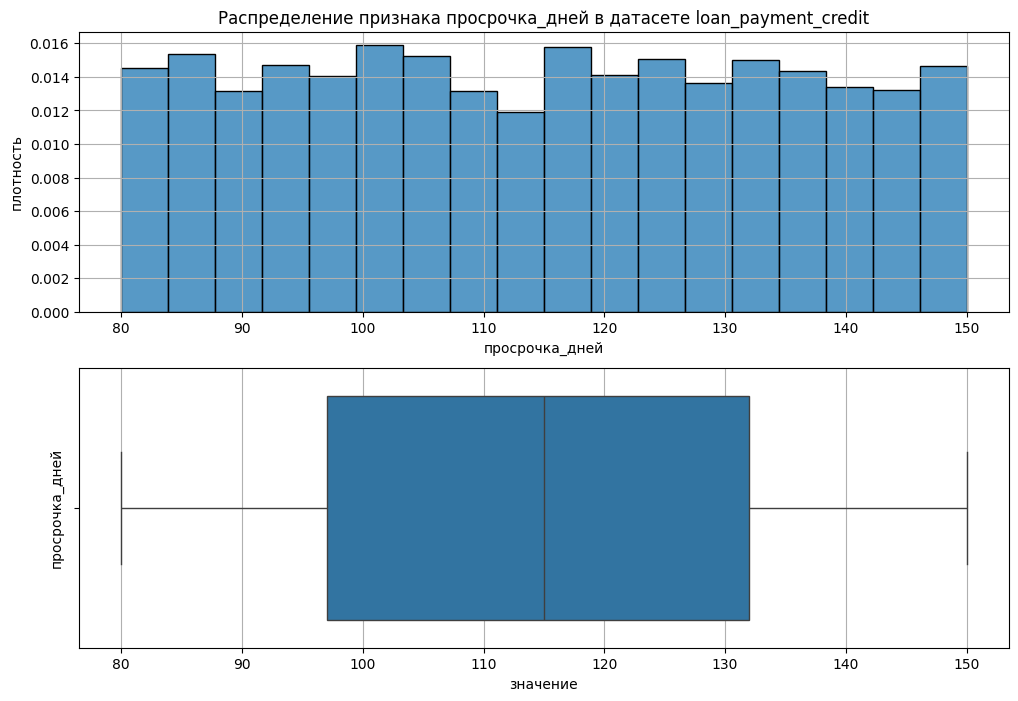

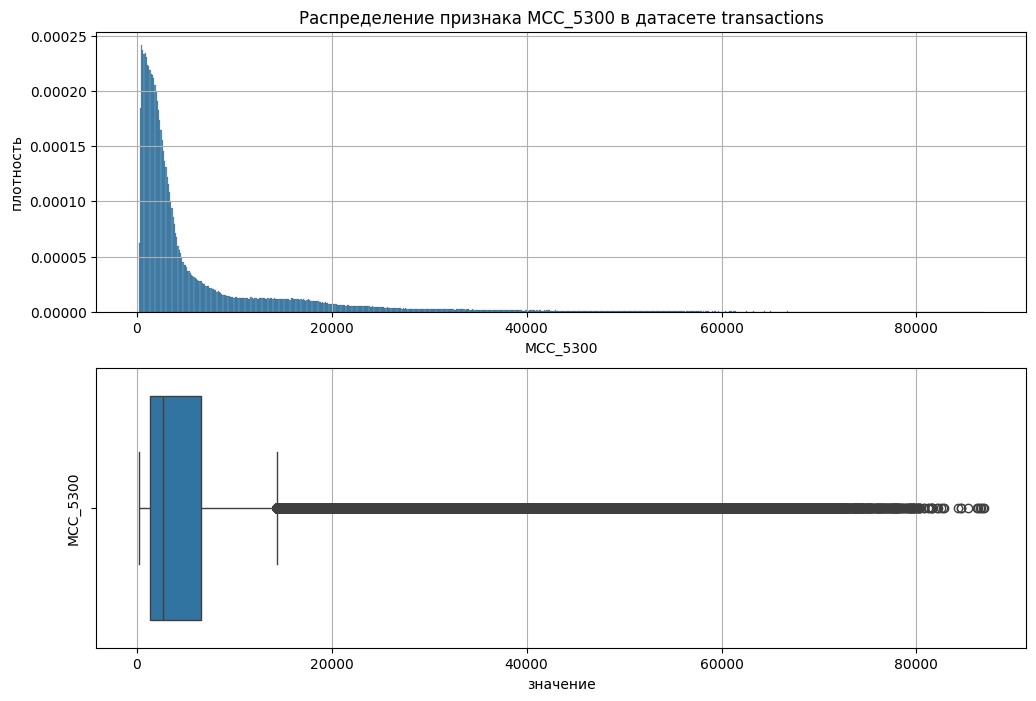

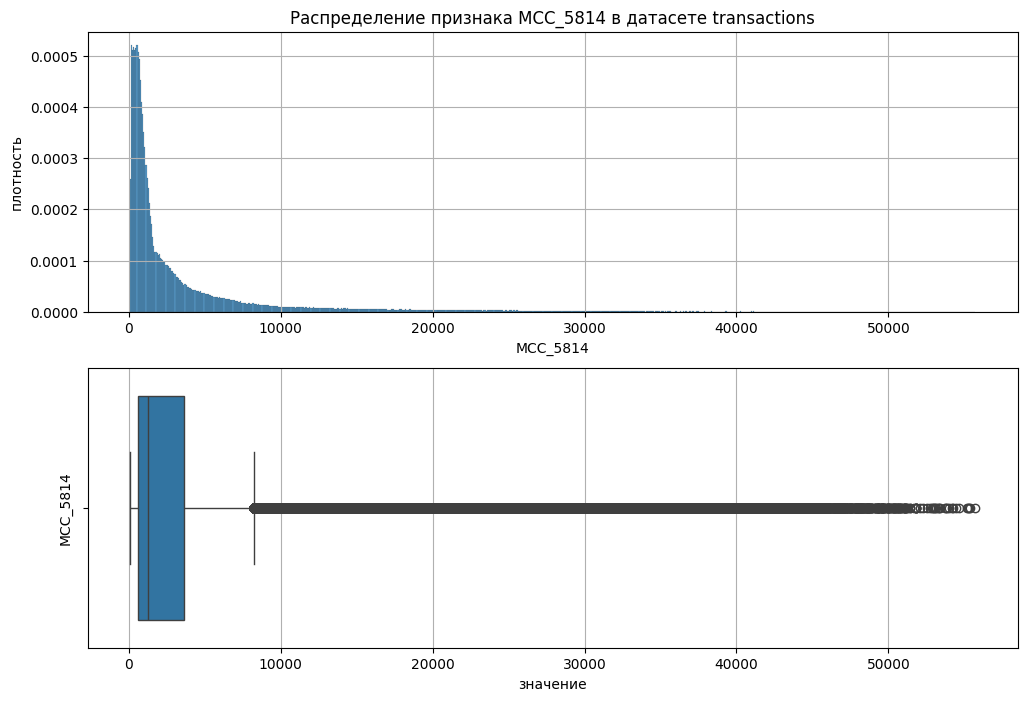

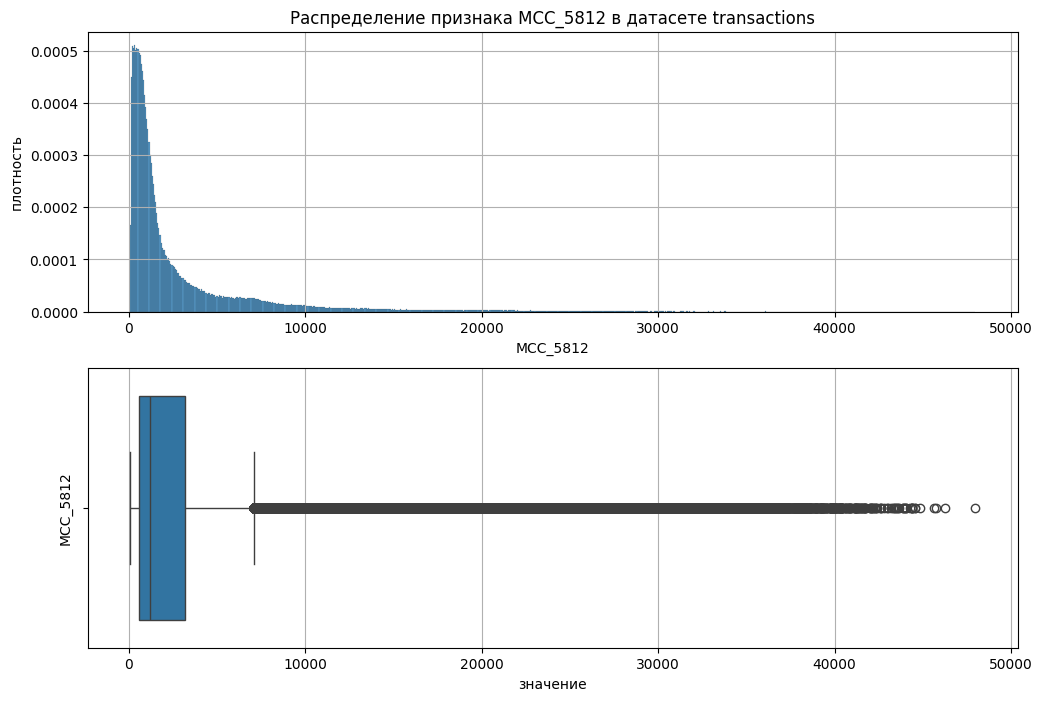

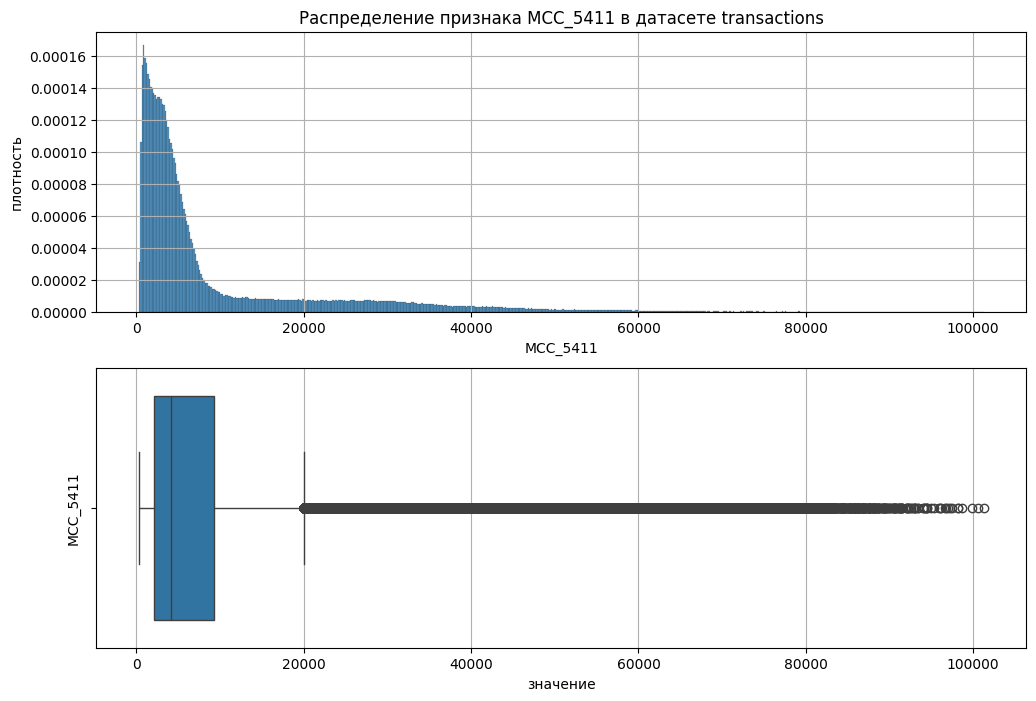

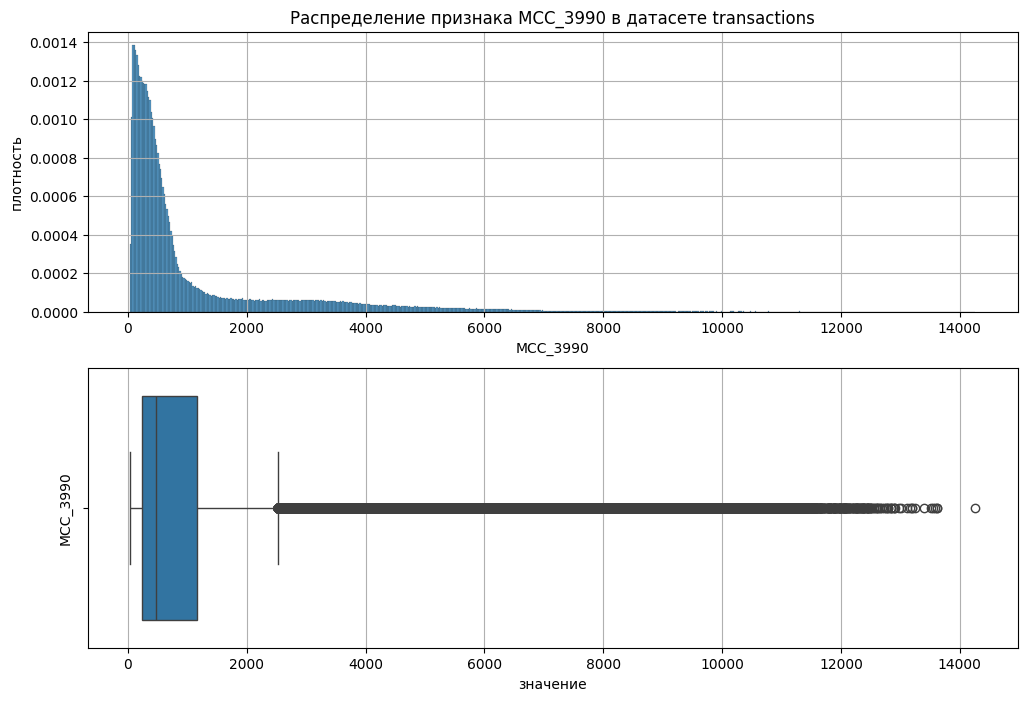

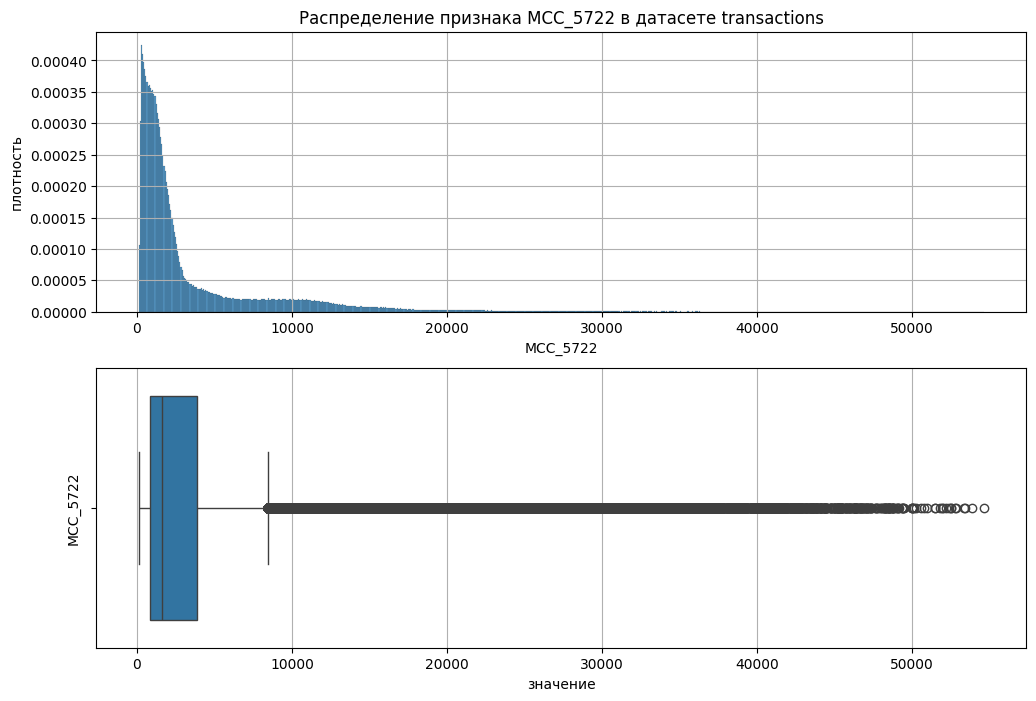

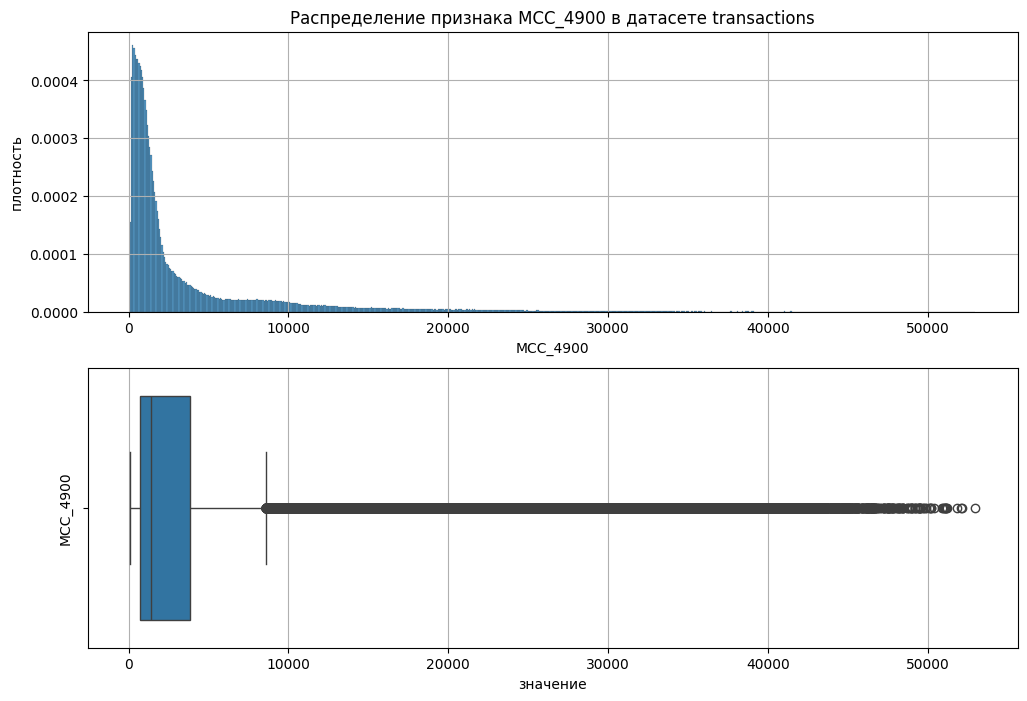

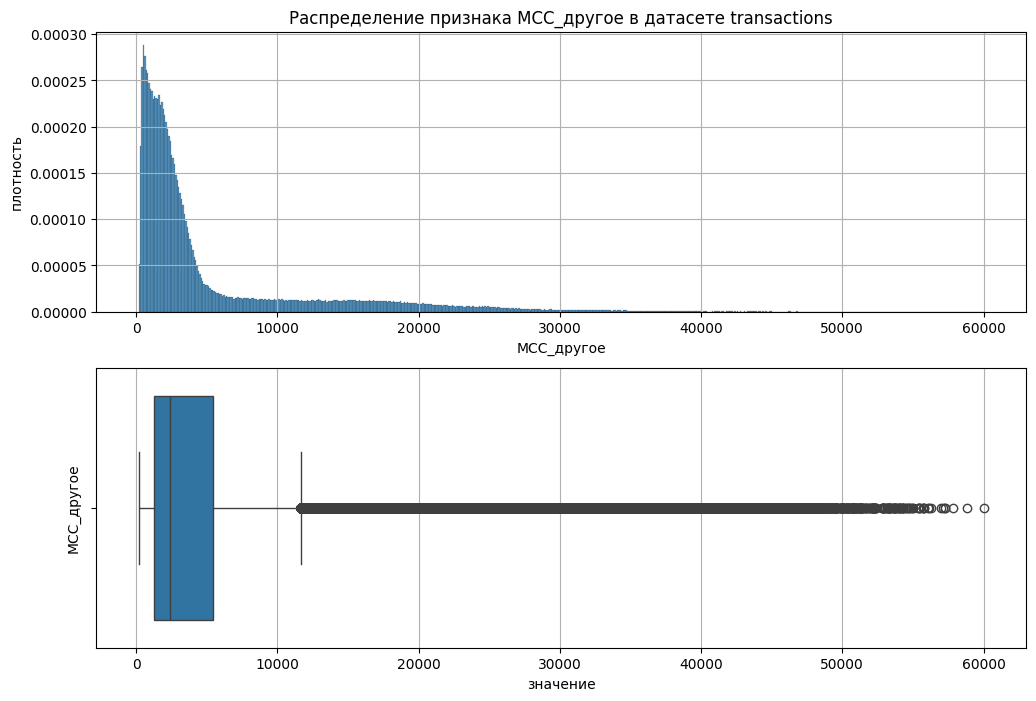

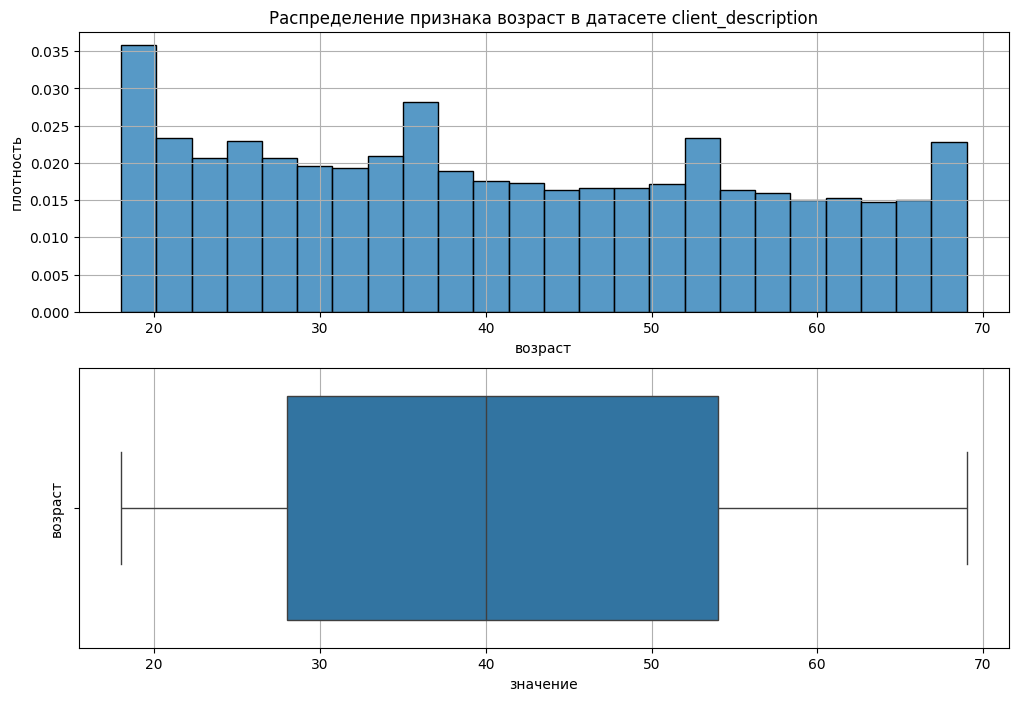

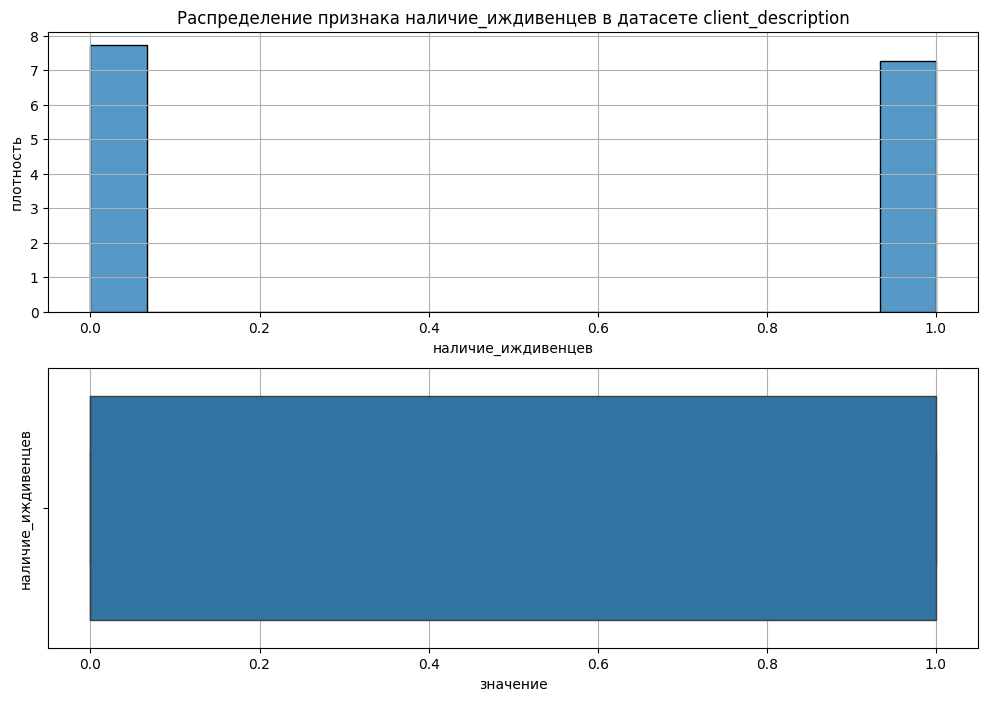

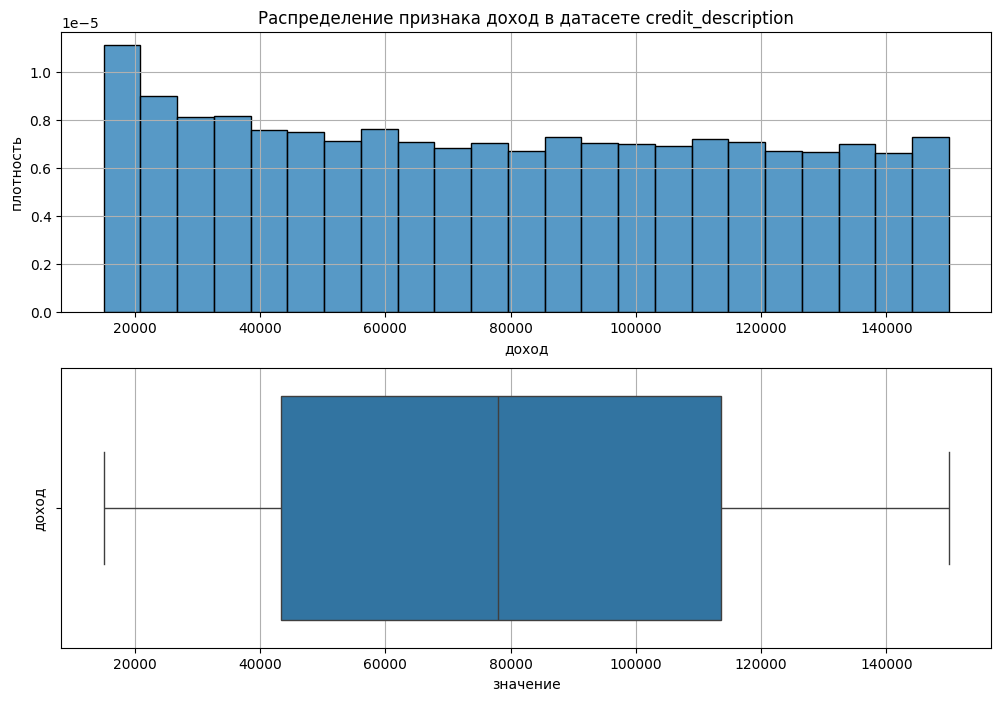

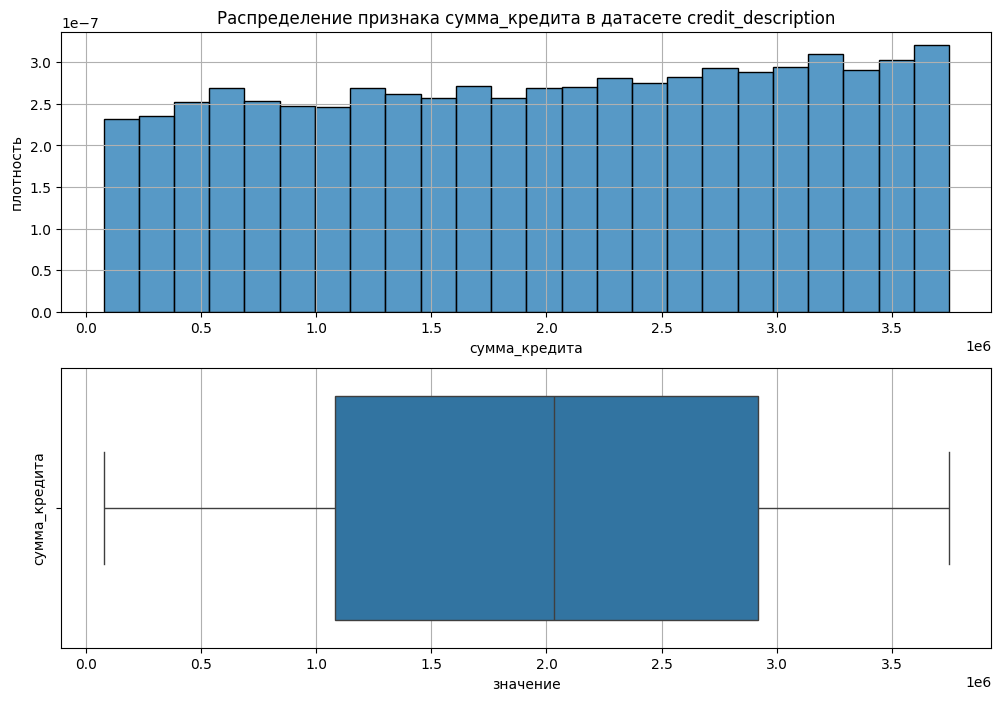

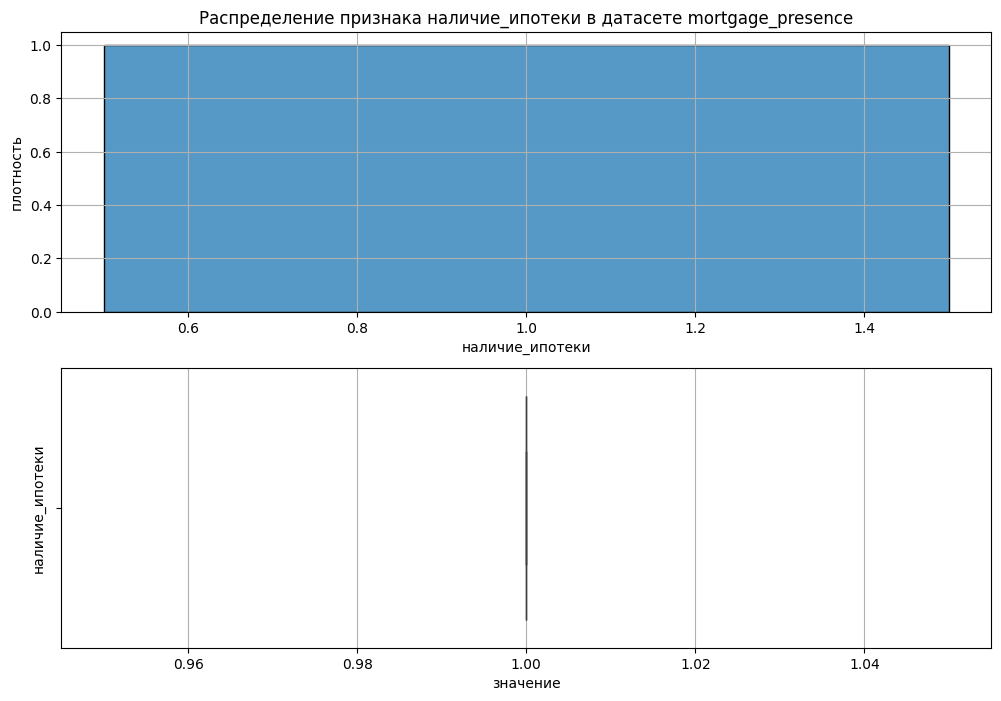

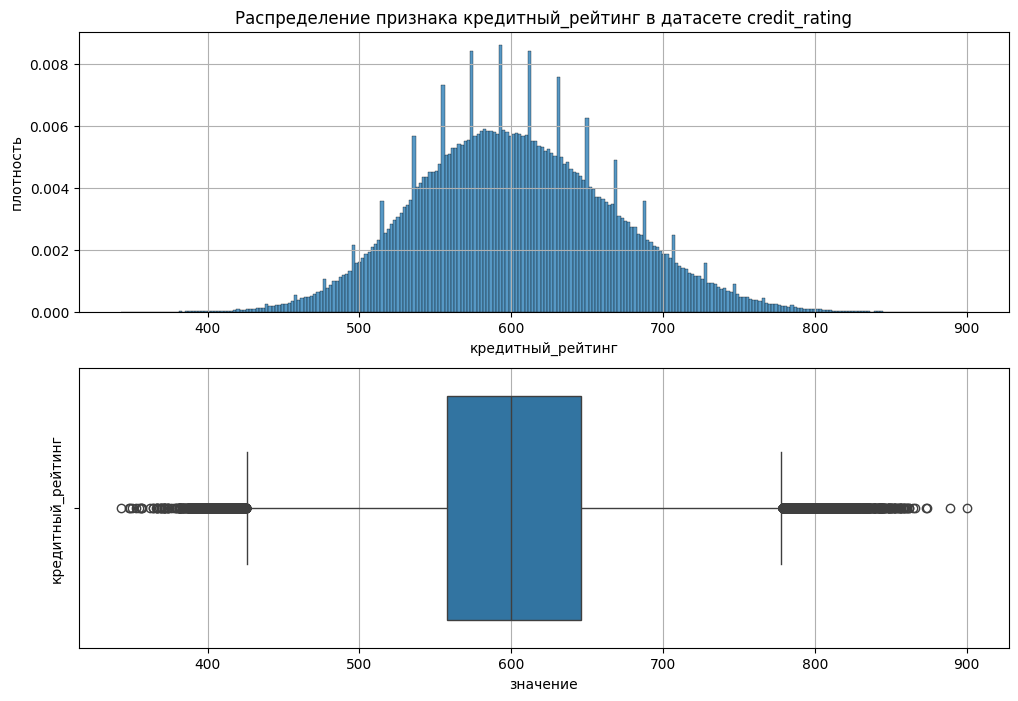

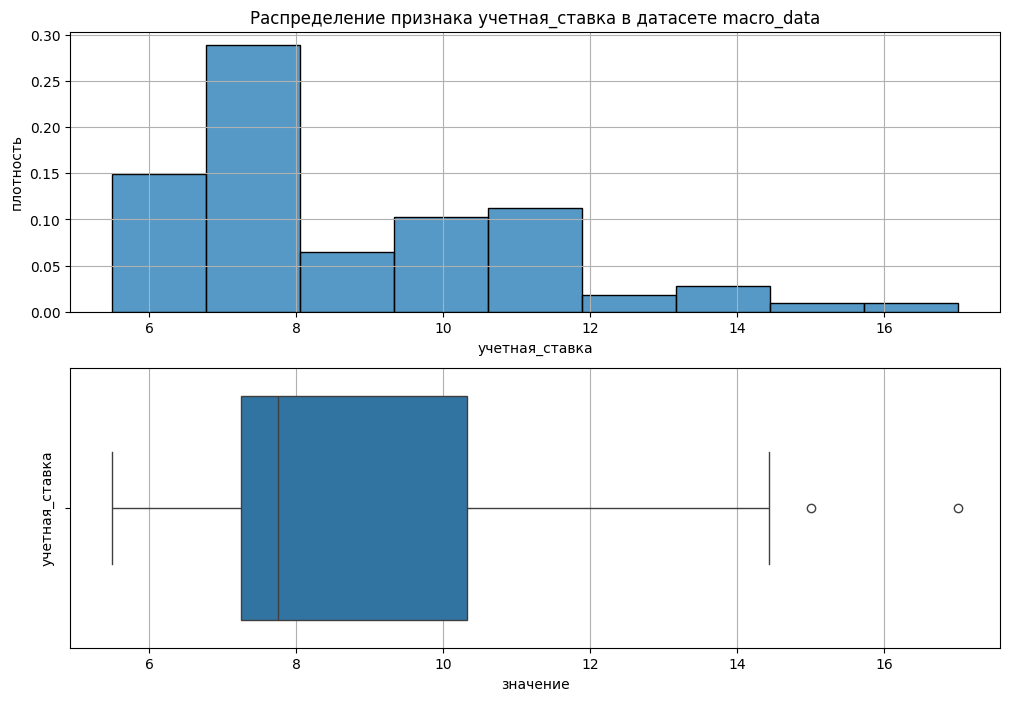

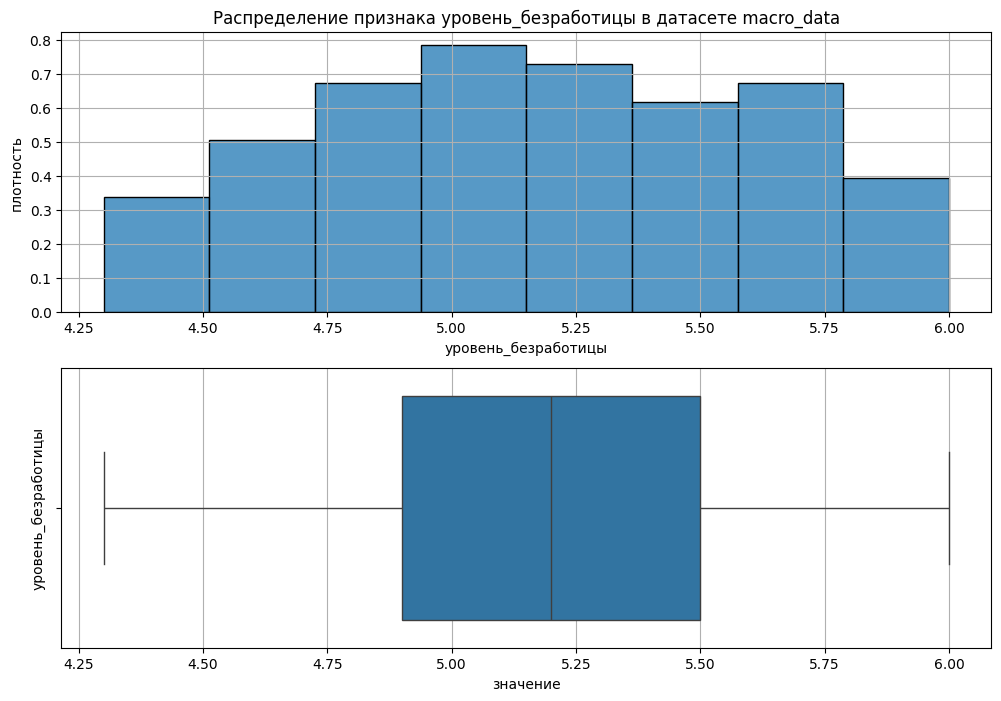

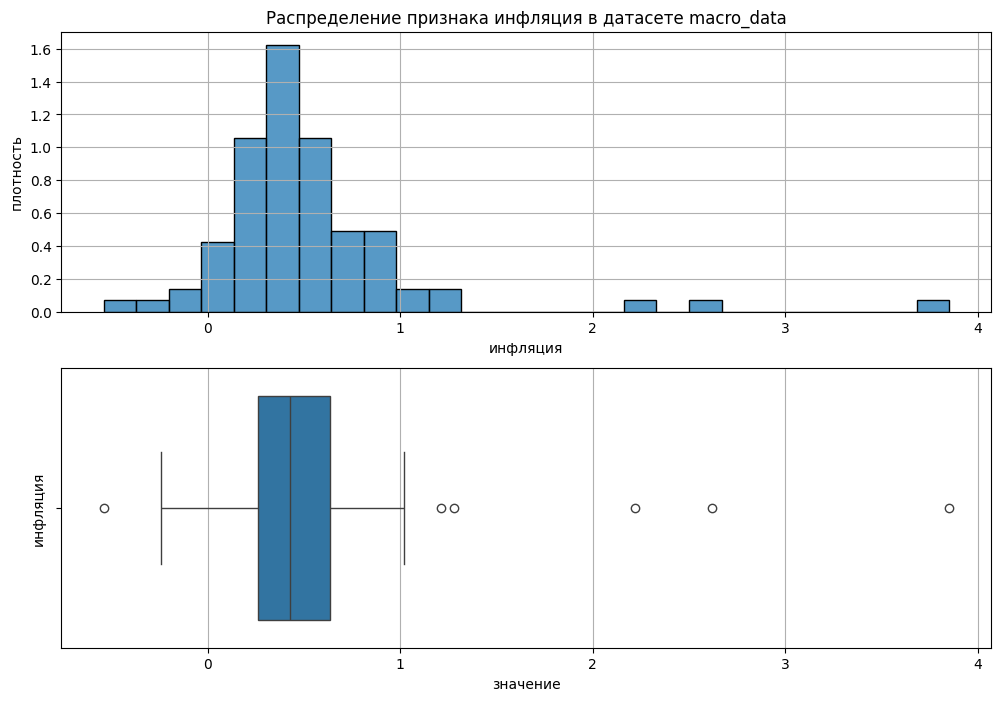

In [18]:
for df, df_name in zip(df_list, df_names):
    _, num_col_names = get_cat_num_cols(df)
    for name in num_col_names:
        plot_hist_box(df=df, feature_name=name, df_name=df_name)

Анализ:
- значение дней просрочек равномерно распределено по диапазону
- траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- возрастные группы представлены равномерно 
- наличие иждевенцев представлено в примерно равных долях 
- по доходу распределение равномерное 
- по сумме кредита распределение равномерное
- данные по наличию ипотеки принимают одно значнение: 1
- распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Возможно, это результат округления или стандратные крейтинги для каких-то категорий граждан
- Распределение по учетной ставке несимметричное, присутствуют малочисленные выбросы (высокая ставка -- достаточно редкое явление)
- По безработице распределение симметричное без выбросов
- По инфляции распределение симметричное, есть выбросы на правом краю диапазона значений

#### Категориальные данные

In [19]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str, df_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    df = df.sort_values(by=name) # сортировка по значениям
    sns.countplot(data=df, x=col_name)
    plt.title(f'Распределение признака {col_name} в датасете {df_name}')
    plt.ylabel('количество')
    plt.xticks(rotation=45)
    plt.show()

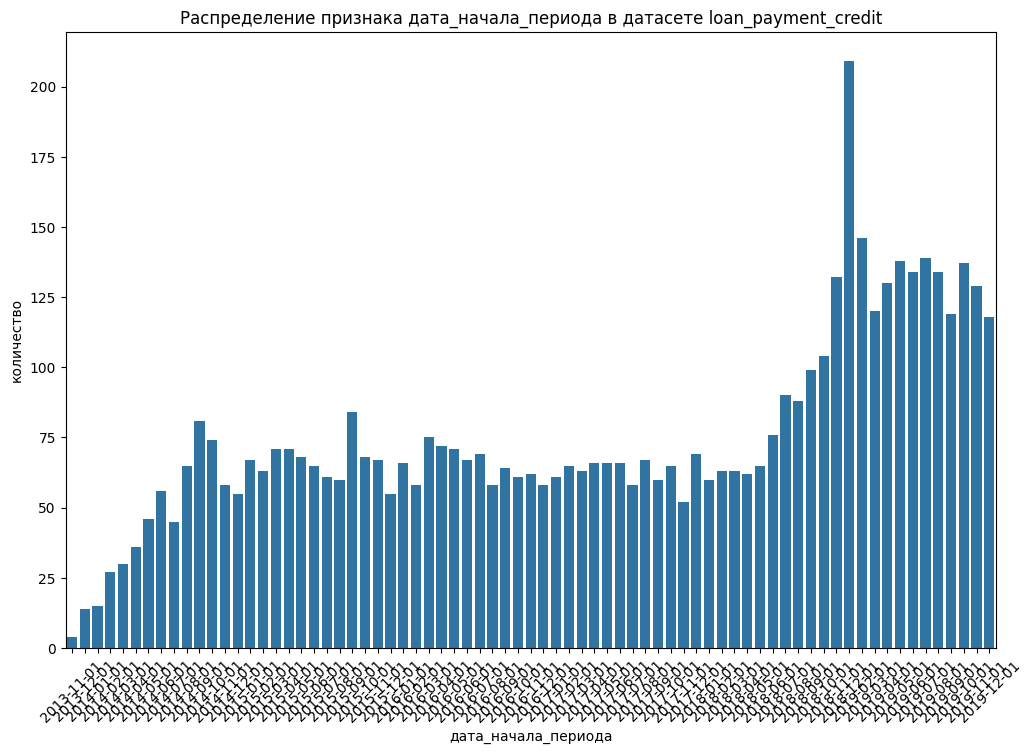

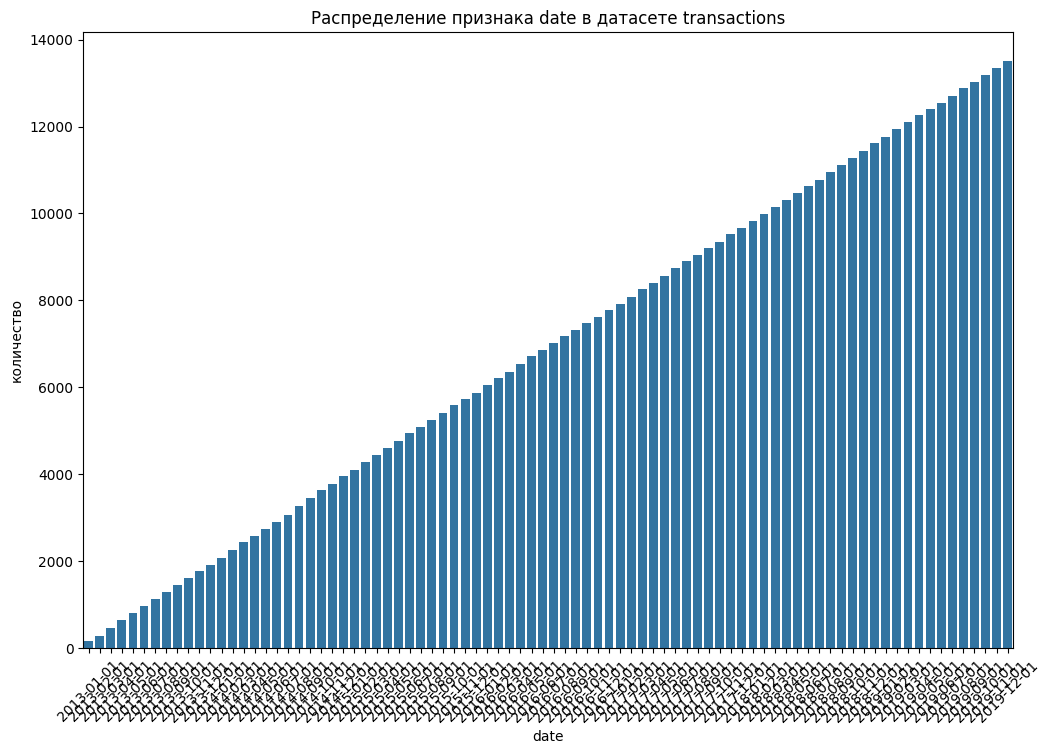

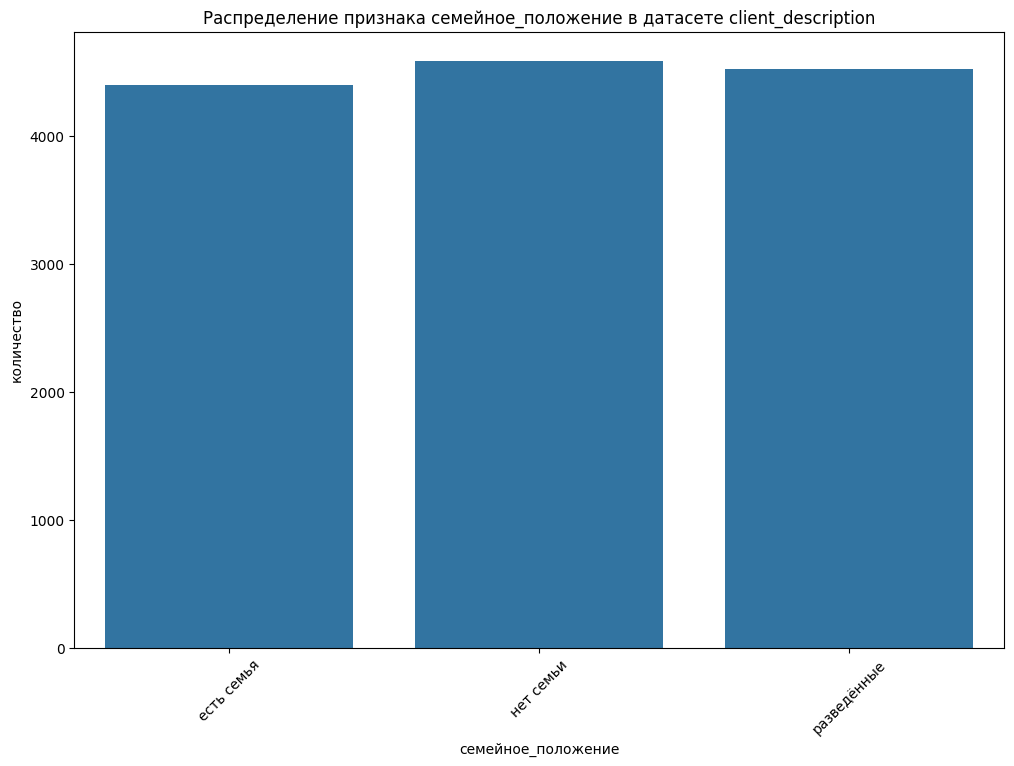

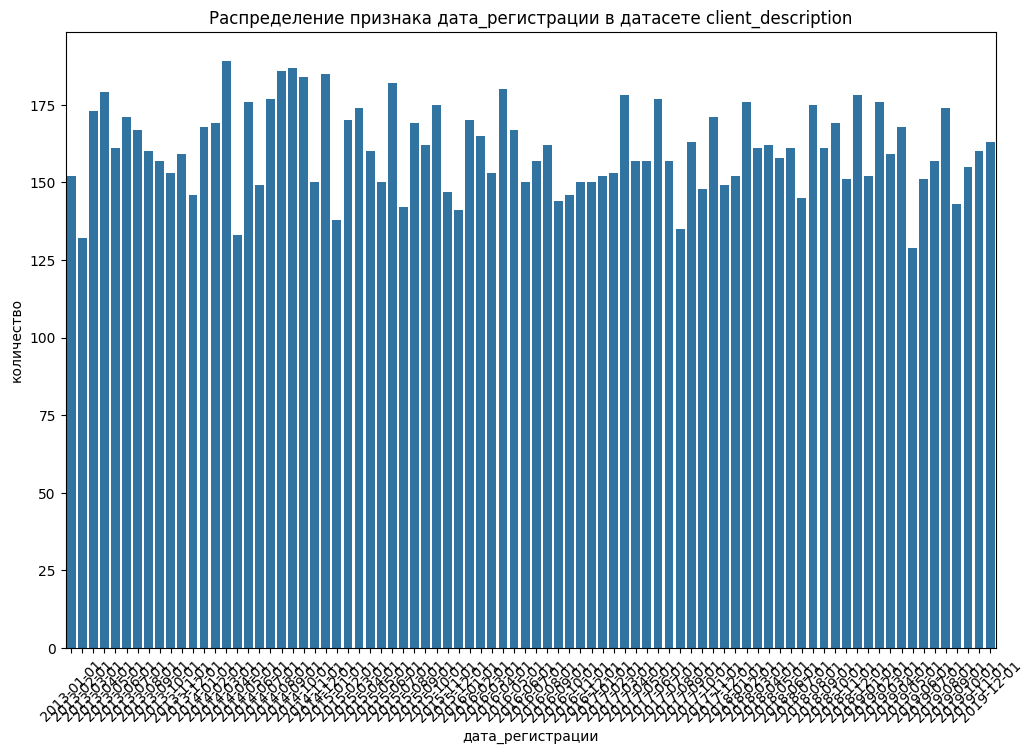

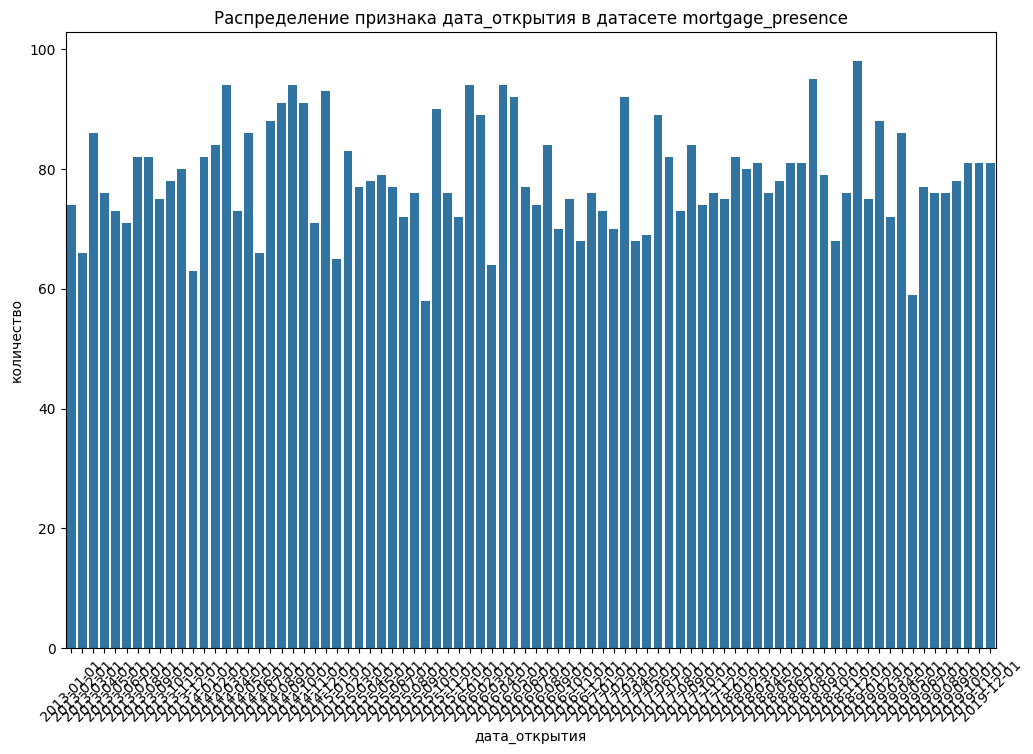

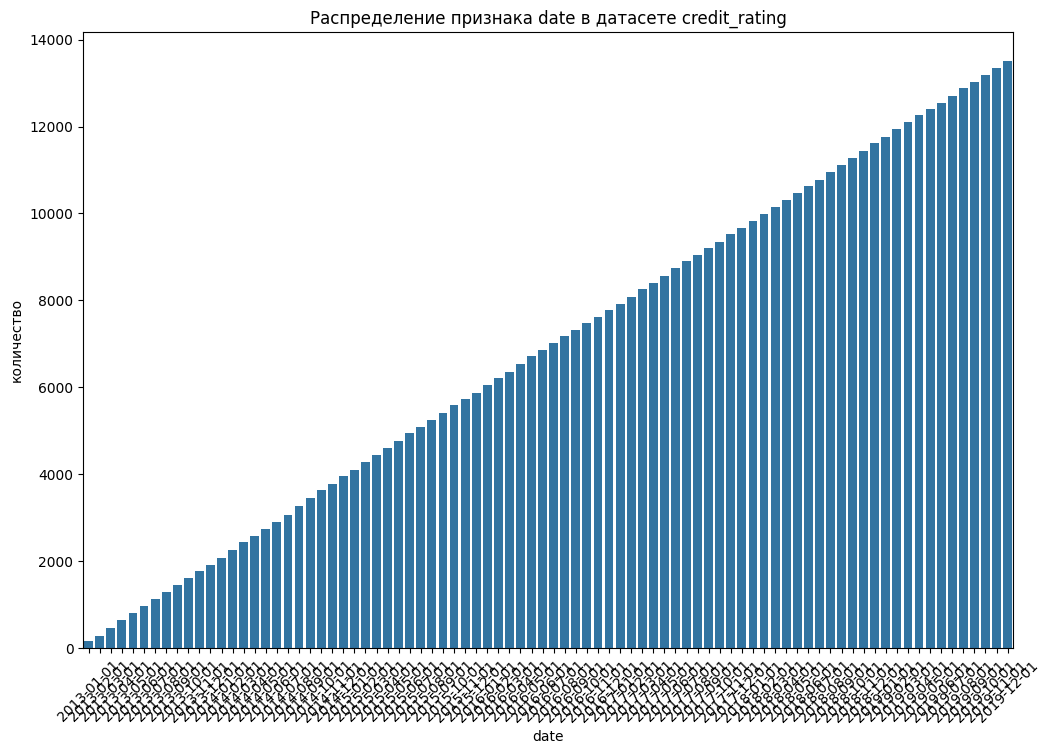

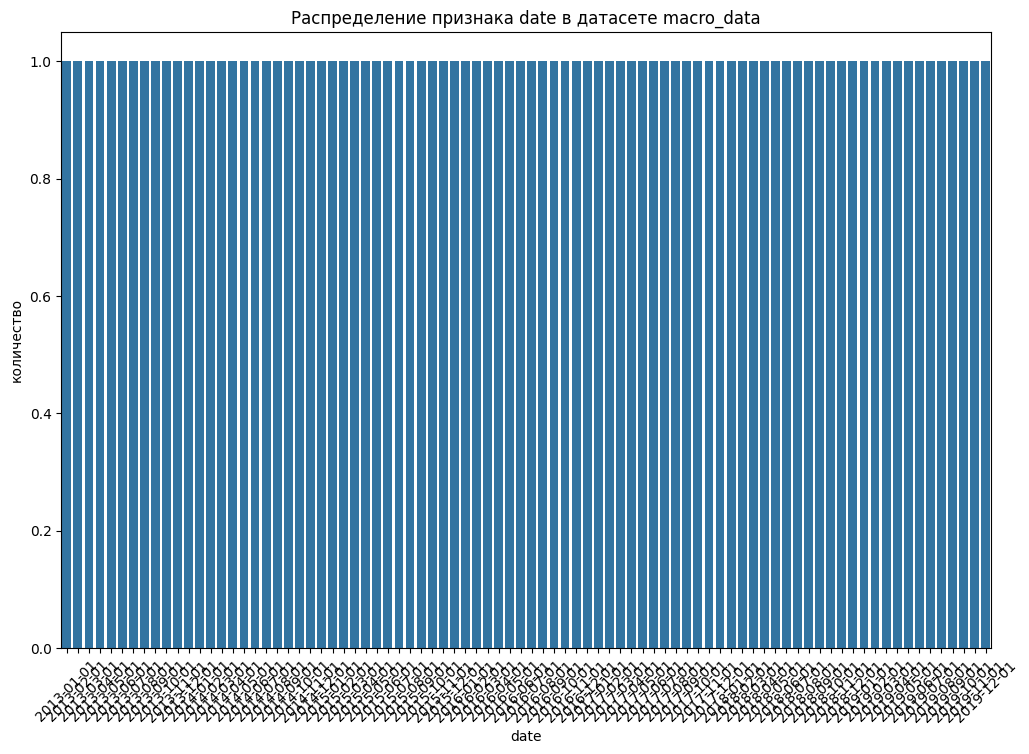

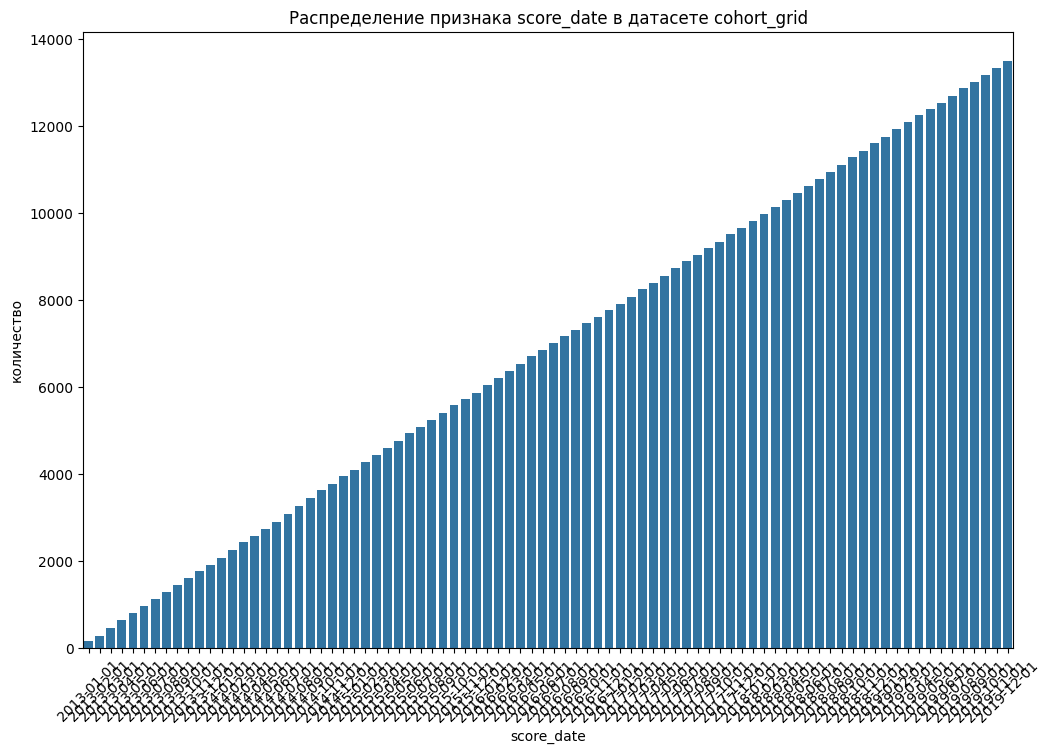

In [20]:
for df, df_name in zip(df_list, df_names):
    cat_col_names, _ = get_cat_num_cols(df)
    cat_col_names = [name for name in cat_col_names if name not in ['ID']]
    for name in cat_col_names:
        plot_count_bars(df=df, col_name=name, df_name=df_name)

Анализ:
- неявных пропусков в виде флагов невалидности нет
- дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- Количество записей о датах транзакций растет линейно 
- по признаку семейного пложения дисбаланса нет 
- даты регистраций распределены равномерно 
- по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- количество дат датасете по кредитным рейтингам растет линейно 
- даты записей макроэкономических показателей равномерно распрелены - по одной записи на дату
- количество дат скоринга растет линейно

### Вывод по ИАД

#### Общие сведения

Данные представлены в виде 8 таблиц:
- Данные о просрочке платежа: loan_payment_credit
- Месячные транзакции клиента: transactions
- Описание клиента на момент регистрации в банке: client_description
- Описание кредита: credit_description
- Данные о наличии ипотеки: mortgage_presence
- Данные о кредитном рейтинге клиента: credit_rating
- Данные о макроэкономических показателях России: macro_data
- Данные о дате проведения поведенческого скоринга: cohort_grid

Типы данных соотвествуют описанию. 

#### Пропуски, дубли

- явных и неявных пропусков/дублей в данных не обнаружено
- неявных дублей по ID и дате нет


#### Анализ распределений

Количественные данные:
- loan_payment_credit: значение дней просрочек равномерно распределено по диапазону
- transactions: траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- client_description: по возрасту распределение равномерное
- client_description: наличие иждевенцев представлено в примерно равных долях 
- credit_description: по доходу и сумме кредита распределение равномерное 
- mortgage_presence: данные по наличию ипотеки принимают одно значнение - 1
- credit_rating: распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Выдвинуто предположение, что в происходило округление или имеются стандратные рейтинги для каких-то категорий граждан.
- macro_data: Распределение по учетной ставке несимметричное и имеет малый набор уникальных значений
- macro_data: По безработице распределение симметричное без выбросов
- macro_data: По инфляции распределение симметричное, есть выбросы 

Категориальные данные:
- loan_payment_credit: дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- transactions: Количество записей о датах транзакций растет линейно 
- client_description: по признаку семейного пложения дисбаланса нет 
- credit_rating: даты регистраций распределены равномерно 
- mortgage_presence: по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- credit_rating: количество дат в датасете по кредитным рейтингам растет линейно 
- macro_data: даты записей макроэкономических показателей равномерно распределены - по одной записи на дату
- cohort_grid: количество дат скоринга растет линейно



<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Для временных таблиц недостаточно проверить только полные дубликаты. Стоит отдельно проверить уникальность ключей:

    ID + дата_начала_периода
    ID + date
    ID + score_date
    date для макроэкономики

Также рекомендую добавить одну таблицу с минимальной и максимальной датой каждого источника

<div class="alert alert-info"> <b>Комментарии студента:</b> Добавил анализ неявных дублей и min-max по дате.</div>

---
## 3. Формирование датасета

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

In [21]:
cohort_grid = df_list[7].copy()
cohort_grid['score_date'] = pd.to_datetime(cohort_grid['score_date'])
loan_payment_credit = df_list[0].rename(columns={'дата_начала_периода': 'начало_периода_просрочки'})
loan_payment_credit['начало_периода_просрочки'] = pd.to_datetime(loan_payment_credit['начало_периода_просрочки'])

In [22]:
def create_target(loan_payment_credit, cohort_grid):
    """Создать таргет дефолта в течение следующих 365 дней."""
    # Первый эпизод просрочки продолжительностью не менее 90 дней.
    first_default = (
        loan_payment_credit.loc[loan_payment_credit['просрочка_дней'].ge(90)]
        .groupby('ID', as_index=False)['начало_периода_просрочки']
        .min()
        .rename(columns={'начало_периода_просрочки': 'first_default_date'})
    )
    df_result = cohort_grid.merge(
        first_default,
        on='ID',
        how='left',
        validate='many_to_one',
    )

    observation_end = loan_payment_credit[
        'начало_периода_просрочки'
    ].max()
    forecast_horizon = df_result['score_date'] + pd.Timedelta(days=365)

    # Оставляем наблюдения с полностью известным горизонтом таргета.
    df_result = df_result[
        forecast_horizon.le(observation_end)
    ].copy()
    forecast_horizon = forecast_horizon.loc[df_result.index]

    # Интервал таргета: [score_date, score_date + 365 дней).
    df_result['target'] = (
        df_result['first_default_date'].ge(df_result['score_date'])
        & df_result['first_default_date'].lt(forecast_horizon)
    ).astype('int8')

    # Исключаем наблюдения после уже произошедшего первого дефолта.
    df_result = df_result[
        df_result['first_default_date'].isna()
        | df_result['first_default_date'].ge(df_result['score_date'])
    ].copy()

    df_result = df_result.drop(columns='first_default_date')

    return df_result

In [23]:
df_result = create_target(loan_payment_credit, cohort_grid)
df_result

,ID,score_date,target
0,IDF55109846,2013-05-01,0
1,IDF55109846,2013-06-01,0
2,IDF55109846,2013-07-01,0
3,IDF55109846,2013-08-01,0
4,IDF55109846,2013-09-01,0
...,...,...,...
577432,IDF54902735,2014-12-01,1
577433,IDF54902735,2015-01-01,1
577434,IDF54902735,2015-02-01,1
577435,IDF54902735,2015-03-01,1


### Создание итоговой таблицы

In [24]:
transactions = df_list[1].copy()
transactions['date'] = pd.to_datetime(transactions['date'])
transactions = transactions.rename(columns={'date': 'date_transactions'})

In [25]:
# столбцы транзакции для агрегации по прошедшим месяцам
mcc_cols = [
    'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
    'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое'
]

transactions = (
    transactions
    .sort_values(['ID', 'date_transactions'])
    .reset_index(drop=True)
)

In [26]:
# проверка, что пары уникальны
transactions.duplicated(['ID', 'date_transactions']).any()

np.False_

In [27]:
# Исключаем текущий месяц: используем только значения до score_date
past_transactions = transactions.groupby('ID')[mcc_cols].shift(1)

features = transactions[['ID', 'date_transactions']].copy()

for window in [3, 6]: # агрегация за периоды
    rolling_sum = (
        past_transactions
        .groupby(transactions['ID'])
        .rolling(window=window, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
        .sort_index()
    )

    rolling_sum.columns = [
        f'{column}_sum_{window}m' for column in mcc_cols
    ]

    features = features.join(rolling_sum)

features = features.rename(columns={'date_transactions': 'score_date'})

In [28]:
rows_before = len(df_result)

df_result = df_result.merge(
    features,
    on=['ID', 'score_date'],
    how='left',
    validate='one_to_one'
)



In [29]:
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,MCC_5812_sum_6m,MCC_5411_sum_6m,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
2,IDF55109846,2013-07-01,0,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,6979.96,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,6979.96
3,IDF55109846,2013-08-01,0,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,10447.02,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,10447.02
4,IDF55109846,2013-09-01,0,10133.10,11251.72,4059.35,16800.12,3222.49,6495.42,10406.90,10144.11,13400.69,12533.83,5517.31,22511.22,3869.92,8870.20,14466.76,13801.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF54902735,2014-12-01,1,122896.80,21981.84,72696.15,144502.50,12132.94,41293.48,32364.61,72542.98,178078.09,86397.48,100165.29,248093.40,24175.76,77782.66,65751.50,145715.22
334692,IDF54902735,2015-01-01,1,151874.80,24585.68,69911.73,142578.60,13646.00,47216.18,35184.47,71440.34,208997.55,68559.02,109235.07,262452.55,23503.50,83544.71,62782.94,149863.06
334693,IDF54902735,2015-02-01,1,133666.48,25171.55,50051.66,128009.83,13273.83,61052.11,35050.78,71661.79,222737.93,56125.73,112092.25,271298.85,24313.46,99909.70,65759.05,150903.71
334694,IDF54902735,2015-03-01,1,111947.81,29694.57,38500.90,141390.71,15198.05,87636.42,38922.82,80982.33,234844.61,51676.41,111197.05,285893.21,27330.99,128929.90,71287.43,153525.31


In [30]:
client_description = df_list[2].copy()
client_description['дата_регистрации'] = pd.to_datetime(client_description['дата_регистрации'])
client_description

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01
...,...,...,...,...,...
13495,IDF55146629,23,нет семьи,1,2013-05-01
13496,IDF54957110,22,разведённые,1,2017-04-01
13497,IDF54917881,39,нет семьи,0,2014-12-01
13498,IDF54902735,27,разведённые,0,2014-03-01


In [31]:
# ближайшая запись в прошлом с информацией о клиенте
df_result = df_result.merge(
    client_description,
    on="ID",
    how="left",
    validate="many_to_one"
)
df_result = df_result.drop(columns='дата_регистрации')

In [32]:
credit_description = df_list[3].copy()
credit_description

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870
...,...,...,...
13495,IDF55146629,36556,2717295
13496,IDF54957110,52944,3168705
13497,IDF54917881,24748,3663045
13498,IDF54902735,133821,389610


In [33]:
df_result = df_result.merge(credit_description, on='ID', how='left', validate='many_to_one')

In [34]:
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,MCC_5411_sum_6m,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,41,разведённые,1,27035,1960785
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,...,5711.10,647.43,2374.78,4059.86,3657.35,41,разведённые,1,27035,1960785
2,IDF55109846,2013-07-01,0,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,...,11535.75,1714.98,4561.89,8652.12,6979.96,41,разведённые,1,27035,1960785
3,IDF55109846,2013-08-01,0,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,...,16745.26,2882.93,6638.43,12257.37,10447.02,41,разведённые,1,27035,1960785
4,IDF55109846,2013-09-01,0,10133.10,11251.72,4059.35,16800.12,3222.49,6495.42,10406.90,...,22511.22,3869.92,8870.20,14466.76,13801.46,41,разведённые,1,27035,1960785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF54902735,2014-12-01,1,122896.80,21981.84,72696.15,144502.50,12132.94,41293.48,32364.61,...,248093.40,24175.76,77782.66,65751.50,145715.22,27,разведённые,0,133821,389610
334692,IDF54902735,2015-01-01,1,151874.80,24585.68,69911.73,142578.60,13646.00,47216.18,35184.47,...,262452.55,23503.50,83544.71,62782.94,149863.06,27,разведённые,0,133821,389610
334693,IDF54902735,2015-02-01,1,133666.48,25171.55,50051.66,128009.83,13273.83,61052.11,35050.78,...,271298.85,24313.46,99909.70,65759.05,150903.71,27,разведённые,0,133821,389610
334694,IDF54902735,2015-03-01,1,111947.81,29694.57,38500.90,141390.71,15198.05,87636.42,38922.82,...,285893.21,27330.99,128929.90,71287.43,153525.31,27,разведённые,0,133821,389610


In [35]:
mortgage_presence = df_list[4].copy()
mortgage_presence

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1
...,...,...,...
6604,IDF55151532,2019-05-01,1
6605,IDF55151572,2017-03-01,1
6606,IDF55151575,2014-02-01,1
6607,IDF55151597,2019-01-01,1


In [36]:
mortgage_presence['дата_открытия'] = pd.to_datetime(
    mortgage_presence['дата_открытия']
)

In [37]:
df_result = df_result.merge(mortgage_presence, on='ID', how='left', validate='many_to_one')
df_result['наличие_ипотеки'] = (
    df_result['дата_открытия'].notna()
    & df_result['дата_открытия'].le(df_result['score_date'])
).astype('int8')
df_result = df_result.drop(columns='дата_открытия')
df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,MCC_3990_sum_6m,MCC_5722_sum_6m,MCC_4900_sum_6m,MCC_другое_sum_6m,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,41,разведённые,1,27035,1960785,0
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,...,647.43,2374.78,4059.86,3657.35,41,разведённые,1,27035,1960785,0
2,IDF55109846,2013-07-01,0,6464.17,3725.48,2792.16,11535.75,1714.98,4561.89,8652.12,...,1714.98,4561.89,8652.12,6979.96,41,разведённые,1,27035,1960785,0
3,IDF55109846,2013-08-01,0,10014.71,8003.20,4255.91,16745.26,2882.93,6638.43,12257.37,...,2882.93,6638.43,12257.37,10447.02,41,разведённые,1,27035,1960785,0
4,IDF55109846,2013-09-01,0,10133.10,11251.72,4059.35,16800.12,3222.49,6495.42,10406.90,...,3869.92,8870.20,14466.76,13801.46,41,разведённые,1,27035,1960785,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF54902735,2014-12-01,1,122896.80,21981.84,72696.15,144502.50,12132.94,41293.48,32364.61,...,24175.76,77782.66,65751.50,145715.22,27,разведённые,0,133821,389610,0
334692,IDF54902735,2015-01-01,1,151874.80,24585.68,69911.73,142578.60,13646.00,47216.18,35184.47,...,23503.50,83544.71,62782.94,149863.06,27,разведённые,0,133821,389610,0
334693,IDF54902735,2015-02-01,1,133666.48,25171.55,50051.66,128009.83,13273.83,61052.11,35050.78,...,24313.46,99909.70,65759.05,150903.71,27,разведённые,0,133821,389610,0
334694,IDF54902735,2015-03-01,1,111947.81,29694.57,38500.90,141390.71,15198.05,87636.42,38922.82,...,27330.99,128929.90,71287.43,153525.31,27,разведённые,0,133821,389610,0


In [38]:
credit_rating = df_list[5].copy()
credit_rating = credit_rating.rename(columns={'date': 'date_credit_rating'})
credit_rating['date_credit_rating'] = pd.to_datetime(
    credit_rating['date_credit_rating']
)
credit_rating

,ID,date_credit_rating,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688
...,...,...,...
577489,IDF54902735,2019-09-01,592
577490,IDF54902735,2019-10-01,592
577491,IDF54902735,2019-11-01,582
577492,IDF54902735,2019-12-01,586


In [39]:
# ближейший кредитный рейтинг в прошлом для заданной даты
df_result = pd.merge_asof(
    df_result.sort_values('score_date'),
    credit_rating.sort_values('date_credit_rating'),
    by='ID',
    left_on='score_date',
    right_on='date_credit_rating',
    direction='backward',
    allow_exact_matches=False,
)
df_result = df_result.drop(columns='date_credit_rating')

In [40]:
# макро экономические показатели за предыдущий известный месяц
macro_data = df_list[6].copy()
macro_data = macro_data.rename(columns={'date': 'macro_date'})
macro_data['macro_date'] = pd.to_datetime(macro_data['macro_date'])

df_result = pd.merge_asof(
    df_result.sort_values('score_date'),
    macro_data.sort_values('macro_date'),
    left_on='score_date',
    right_on='macro_date',
    direction='backward',
    allow_exact_matches=False
)
df_result = df_result.drop(columns='macro_date')


In [42]:
df_result.columns

Index(['ID', 'score_date', 'target', 'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
       'MCC_5812_sum_3m', 'MCC_5411_sum_3m', 'MCC_3990_sum_3m',
       'MCC_5722_sum_3m', 'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
       'MCC_5300_sum_6m', 'MCC_5814_sum_6m', 'MCC_5812_sum_6m',
       'MCC_5411_sum_6m', 'MCC_3990_sum_6m', 'MCC_5722_sum_6m',
       'MCC_4900_sum_6m', 'MCC_другое_sum_6m', 'возраст', 'семейное_положение',
       'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки',
       'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы',
       'инфляция'],
      dtype='object')

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Статические данные клиента присоединяются некорректно:

    pd.merge_asof(
        ...,
        left_on="score_date",
        right_on="дата_регистрации",
        allow_exact_matches=False
    )

Возраст, семейное положение и наличие иждивенцев известны уже в дату регистрации. Но из-за allow_exact_matches=False они не присоединяются для первого месяца клиента

Именно поэтому у 11 613 наблюдений отсутствуют все клиентские признаки, хотя в исходной таблице пропусков нет. Для статических данных лучше использовать обычный merge по ID:

    df_result = df_result.merge(
        client_description,
        on="ID",
        how="left",
        validate="many_to_one"
    )

После этого стоит проверить, что score_date >= дата_регистрации, и удалить технический столбец с датой.

---

Ипотека учитывается только при условии:

    дата_открытия < score_date

Ипотека, открытая ровно в дату скоринга, уже известна на эту дату. Здесь должно быть:

    дата_открытия <= score_date

Сейчас первый месяц ипотеки ошибочно получает значение 0

<div class="alert alert-info"> <b>Комментарии студента:</b> Скорректировал присоединение статических данных. Уловие при присоединении ипотеки скорректировал </div>

### Создание новых признаков

1. Признак:
- **income_diff = доход_за_3_месяца  / суммарные_траты_по_всем_категориям_за_3_месяца**

Предположение:
- если в течение какого-то срока траты клиента превосходят его доход, то в будущем возрастает вероятность неплатежа по задолженности 

In [43]:
# отношение суммарного дохода к тратам за 3 месяца
mcc_3m_cols = [
    'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
    'MCC_5812_sum_3m', 'MCC_5411_sum_3m',
    'MCC_3990_sum_3m', 'MCC_5722_sum_3m',
    'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
]

spend_3m = df_result[mcc_3m_cols].sum(axis=1, min_count=1)

df_result['income_spend_ratio_3m'] = (
    3 * df_result['доход'] / spend_3m.replace(0, np.nan)
)

In [44]:
df_result.columns

Index(['ID', 'score_date', 'target', 'MCC_5300_sum_3m', 'MCC_5814_sum_3m',
       'MCC_5812_sum_3m', 'MCC_5411_sum_3m', 'MCC_3990_sum_3m',
       'MCC_5722_sum_3m', 'MCC_4900_sum_3m', 'MCC_другое_sum_3m',
       'MCC_5300_sum_6m', 'MCC_5814_sum_6m', 'MCC_5812_sum_6m',
       'MCC_5411_sum_6m', 'MCC_3990_sum_6m', 'MCC_5722_sum_6m',
       'MCC_4900_sum_6m', 'MCC_другое_sum_6m', 'возраст', 'семейное_положение',
       'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки',
       'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы',
       'инфляция', 'income_spend_ratio_3m'],
      dtype='object')

2. Признаки динамики кредитного рейтинга:
- **rating_mean_6m** -- средний рейтинг за 6 месяцев;
- **rating_std_6m** -- волатильность рейтинга за 6 месяцев.

Предположение:
- снижение рейтинга и высокая волатильность могут сигнализировать об ухудшении платёжного поведения клиента.

In [45]:
rating_history = df_result[
    ['ID', 'score_date', 'кредитный_рейтинг']
].sort_values(['ID', 'score_date'])

rating_by_client = rating_history.groupby('ID')['кредитный_рейтинг']

rating_history['rating_mean_6m'] = (
    rating_by_client
    .rolling(window=6, min_periods=2)
    .mean()
    .reset_index(level=0, drop=True)
)
rating_history['rating_std_6m'] = (
    rating_by_client
    .rolling(window=6, min_periods=2)
    .std()
    .reset_index(level=0, drop=True)
)

rating_feature_cols = [
    'rating_mean_6m',
    'rating_std_6m',
]
df_result[rating_feature_cols] = rating_history[rating_feature_cols]

df_result

,ID,score_date,target,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
0,IDF55059710,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69734,3676065,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF54910959,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,123096,2000415,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDF54992721,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61259,992700,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDF54976809,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60433,3297510,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDF55106956,2013-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27401,3242925,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF55080464,2018-12-01,1,19263.11,14009.49,12687.97,38625.79,3244.32,10961.73,8813.48,...,33542,2422080,0,653.0,7.5,4.8,0.5,0.761445,680.166667,15.144856
334692,IDF54968033,2018-12-01,0,3291.78,1685.04,1318.75,5600.56,720.56,3104.10,3035.18,...,43508,3056565,0,568.0,7.5,4.8,0.5,5.923386,563.500000,4.969909
334693,IDF54979278,2018-12-01,0,60951.94,12607.50,22416.39,60118.70,6569.85,30289.19,16573.38,...,112415,2153430,0,651.0,7.5,4.8,0.5,1.374851,682.333333,18.853824
334694,IDF55097495,2018-12-01,0,2906.29,3558.76,1226.85,5399.40,1013.79,1951.09,3364.32,...,53105,2286450,1,516.0,7.5,4.8,0.5,7.036726,510.833333,11.160944


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, что исходный рейтинг уже сдвинут относительно даты скоринга, поэтому rolling-признаки не используют будущую информацию

### Анализ итоговой таблицы

Проверка целевой переменой

In [46]:
df_result['target'].sum() / len(df_result['target']) * 100

np.float64(13.255013504792409)

Анализ:
- наблюдается дисбаланс классов в целевой переменной

Рекомендация:
- необходимо воспользоваться оверсэмплингом/андерсэмплингом в пайплайне предобработки данных для улучшения качества предсказания

In [47]:
# контроль отсутствия дублей
df_result.duplicated(['ID', 'score_date']).any()

np.False_

In [48]:
# колонки с пропусками 
len(df_result.columns[df_result.isna().any()].to_list())

23

In [49]:
df_result.isna().any(axis=1).sum() / len(df_result)

np.float64(0.06886249014030643)

#### Промежуточный итог по созданию общей таблицы

- таблица состоит из 29 столбцов-признаков, характеризующих клиентов и макроэкономическую ситуацию в стране 
- кроме того, таблица содержит: target - целевая переменная, score_date - дата оценки, ID - идентификатор пользователя
- в рамках целевой переменной есть дисбаланс. В пайплайн обучения необходимо встроить методы балансировки 
- большинство колонок содержат пропуски. Связано это с отсутствием достаточной прошлой историей клиента. Поскольку доля строк с пропусками мала (около 7%), такие строки принято решение удалить

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Сейчас твой вывод о том, что временные пропуски можно обработать обычной медианой, неверен.

Смотри, у теб пропуски в MCC, рейтинге и rolling-признаках возникают не случайно. Они означают, что у клиента ещё нет достаточной прошлой истории. Медианная импутация создаёт вымышленное "среднее прошлое":

    клиент без транзакционной истории получает средние расходы
    клиент без рейтинговой истории получает средний рейтинг
    первый месяц клиента становится похож на обычный зрелый период

Нужно выбрать один из вариантов которые я вижу тут:

* удалить строки, где полностью отсутствует прошлая поведенческая история
* либо заполнить MCC значением 0, рейтинг специальным значением вроде -1 и добавить флаги отсутствия истории
* добавить количество доступных месяцев истории
* для окон 3 и 6 месяцев указать, сколько фактических месяцев вошло в расчёт

Пропуски в статических клиентских признаках сначала нужно устранить исправлением merge, а не импутацией. После этой правки витрину и все модели нужно пересчитать.

<div class="alert alert-info"> <b>Комментарии студента:</b> Пропусков в строках относительно немного. Принял решение удалить такие строки  </div>

---
## 4. Пайплайн предобработки данных

In [50]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     334696 non-null  object        
 1   score_date             334696 non-null  datetime64[ns]
 2   target                 334696 non-null  int8          
 3   MCC_5300_sum_3m        323083 non-null  float64       
 4   MCC_5814_sum_3m        323083 non-null  float64       
 5   MCC_5812_sum_3m        323083 non-null  float64       
 6   MCC_5411_sum_3m        323083 non-null  float64       
 7   MCC_3990_sum_3m        323083 non-null  float64       
 8   MCC_5722_sum_3m        323083 non-null  float64       
 9   MCC_4900_sum_3m        323083 non-null  float64       
 10  MCC_другое_sum_3m      323083 non-null  float64       
 11  MCC_5300_sum_6m        323083 non-null  float64       
 12  MCC_5814_sum_6m        323083 non-null  floa

In [51]:
# убираем пропуски
init_len = len(df_result)
df_result = df_result.dropna()
result_len = len(df_result)
print('Потери при очистке от пропусков (%)', (init_len - result_len) / init_len * 100 )

Потери при очистке от пропусков (%) 6.886249014030643


In [52]:
# проверка отсутствия пропусков
df_result.isna().sum().sum()

np.int64(0)

In [53]:
get_cat_num_cols(df=df_result)

(['ID', 'семейное_положение'],
 ['target',
  'MCC_5300_sum_3m',
  'MCC_5814_sum_3m',
  'MCC_5812_sum_3m',
  'MCC_5411_sum_3m',
  'MCC_3990_sum_3m',
  'MCC_5722_sum_3m',
  'MCC_4900_sum_3m',
  'MCC_другое_sum_3m',
  'MCC_5300_sum_6m',
  'MCC_5814_sum_6m',
  'MCC_5812_sum_6m',
  'MCC_5411_sum_6m',
  'MCC_3990_sum_6m',
  'MCC_5722_sum_6m',
  'MCC_4900_sum_6m',
  'MCC_другое_sum_6m',
  'возраст',
  'наличие_иждивенцев',
  'доход',
  'сумма_кредита',
  'наличие_ипотеки',
  'кредитный_рейтинг',
  'учетная_ставка',
  'уровень_безработицы',
  'инфляция',
  'income_spend_ratio_3m',
  'rating_mean_6m',
  'rating_std_6m'])

In [54]:
# сортировка датасета
df_result.sort_values(by=['score_date', 'ID'], inplace=True)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_69137/114524662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result.sort_values(by=['score_date', 'ID'], inplace=True)


In [55]:
# числовые признаки, которые по смыслу явяются категориальными
NUM_SPECIAL_MOST_FREQ = ['наличие_иждивенцев'] # замена пропусков на наиболее часто встречающееся значение
NUM_SPECIAL_ZERO = ['наличие_ипотеки']  # замена на флаг отсутсвия - 0

In [56]:
# отбор признаков

def select_cat_one_hot(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_num_classic(X):
    num_cols_continues = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    special_num_cats = NUM_SPECIAL_ZERO + NUM_SPECIAL_MOST_FREQ
    return [name for name in num_cols_continues if name not in special_num_cats]

def select_num_special_zero(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_SPECIAL_ZERO]

def select_num_special_mf(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_SPECIAL_MOST_FREQ]

In [57]:
class IQROutliersReplacer(BaseEstimator, TransformerMixin):
    """Фильтрация выбросов по межквартильному размаху с заданным коэффициентом"""
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bound_ = None
        self.upper_bound_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bound_ = q1 - self.factor * iqr
        self.upper_bound_ = q3 + self.factor * iqr
        
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        for col in X.columns:
            X.loc[(X[col] < self.lower_bound_[col]) | (X[col] > self.upper_bound_[col]), col] = np.nan
        return X


In [58]:
def create_preprocessing_pipeline(
        with_outliers_filtering: bool = False
):
    """
    Создание трансформера предобработки данных.

    Args:
        with_outliers_filtering (bool): флаг наличия фильтации выбросов

    Returns:
        ColumnTransformer: Трансформер предобработки данных
    """
    # категориальные признаки

    # малочисленные
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])

    # количественные данные, которые по смыслу являются категориальными
    # замена пропусков на наиболее часто встречающееся значение
    num_special_mf_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler()),
    ])

    # особые признаки: отсутстие значения = 0
    num_special_zero_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', MinMaxScaler()),
    ])

    # количественные признаки с возможными выбросами
    num_classic_steps = []
    if with_outliers_filtering:
        num_classic_steps.append(
            ('outliears', IQROutliersReplacer())
        )
    num_classic_steps += [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ]

    num_classic_pipeline = Pipeline(steps=num_classic_steps)

    transformers = [
        ('cat_one_hot_pipeline', cat_one_hot_pipeline, select_cat_one_hot),
        ('num_special_mf_pipeline', num_special_mf_pipeline, select_num_special_mf),
        ('num_special_zero_pipeline', num_special_zero_pipeline, select_num_special_zero),
        ('num_classic_pipeline', num_classic_pipeline, select_num_classic),
    ]
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    return preprocessor


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Предобработка помещена внутрь ColumnTransformer и обучается только на train-фолде. так держать!)

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
SimpleImputer(strategy="median") применяется ко всем числовым признакам, включая временные поведенческие признаки без истории

Это продолжение критичной проблемы предыдущего раздела. Обработку отсутствующей истории нужно разделить по смыслу признаков, а не применять одну медиану ко всему числовому блоку

<div class="alert alert-info"> <b>Комментарии студента:</b> Признаки без истории удалены  </div>

--- 
## 5. Базовые модели


### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

#### Разбиение выборки на train/test

In [59]:
df_result = df_result.sort_values(['score_date', 'ID']).reset_index(drop=True)

In [60]:
metadata = df_result[['ID', 'score_date']].copy()
months = metadata['score_date'].dt.strftime('%Y-%m')

groups, _ = pd.factorize(months)

X = df_result.drop(columns=['target', 'ID', 'score_date']).set_index(months)
y = pd.Series(df_result['target'], name='target')
display(X.head(), y.head())

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2013-03,24528.61,14098.57,9181.80,41740.09,6089.73,16604.50,30646.35,24473.79,24528.61,14098.57,...,88630,3174630,1,677.0,5.5,5.8,0.56,1.588698,671.0,8.485281
2013-03,27474.97,16215.81,11327.36,51234.10,6841.45,17629.84,38784.39,29627.20,27474.97,16215.81,...,118478,1484085,1,702.0,5.5,5.8,0.56,1.784889,696.5,7.778175
2013-03,35363.52,21536.88,14047.52,64491.75,9071.24,22383.40,45206.71,38074.80,35363.52,21536.88,...,149716,2326665,1,680.0,5.5,5.8,0.56,1.795329,682.5,3.535534
2013-03,20639.97,11961.27,8168.86,36499.48,5087.09,12778.66,28233.81,21506.03,20639.97,11961.27,...,84077,265020,0,686.0,5.5,5.8,0.56,1.741023,688.5,3.535534
2013-03,19087.21,10442.59,7377.09,32083.30,4940.05,11836.10,24892.86,19088.86,19087.21,10442.59,...,70568,3656715,1,670.0,5.5,5.8,0.56,1.631654,675.5,7.778175


0    1
1    0
2    0
3    0
4    0
Name: target, dtype: int8

In [61]:
# Разделение по календарным месяцам.

test_months = 12
calib_months = 12

test_start_month = months.unique()[-test_months]
calib_start_month = months.unique()[-test_months-calib_months]

train_mask = months < calib_start_month
calib_mask = (months >= calib_start_month) & (months < test_start_month)
test_mask = months >= test_start_month


In [62]:
X_train = X[train_mask.values]
y_train = y[train_mask.values]
train_groups = groups[train_mask.values]

display(X_train.head(), y_train.head(), train_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2013-03,24528.61,14098.57,9181.80,41740.09,6089.73,16604.50,30646.35,24473.79,24528.61,14098.57,...,88630,3174630,1,677.0,5.5,5.8,0.56,1.588698,671.0,8.485281
2013-03,27474.97,16215.81,11327.36,51234.10,6841.45,17629.84,38784.39,29627.20,27474.97,16215.81,...,118478,1484085,1,702.0,5.5,5.8,0.56,1.784889,696.5,7.778175
2013-03,35363.52,21536.88,14047.52,64491.75,9071.24,22383.40,45206.71,38074.80,35363.52,21536.88,...,149716,2326665,1,680.0,5.5,5.8,0.56,1.795329,682.5,3.535534
2013-03,20639.97,11961.27,8168.86,36499.48,5087.09,12778.66,28233.81,21506.03,20639.97,11961.27,...,84077,265020,0,686.0,5.5,5.8,0.56,1.741023,688.5,3.535534
2013-03,19087.21,10442.59,7377.09,32083.30,4940.05,11836.10,24892.86,19088.86,19087.21,10442.59,...,70568,3656715,1,670.0,5.5,5.8,0.56,1.631654,675.5,7.778175


0    1
1    0
2    0
3    0
4    0
Name: target, dtype: int8

array([ 0,  0,  0, ..., 45, 45, 45])

In [63]:
X_calib = X[calib_mask.values]
y_calib = y[calib_mask.values]
calib_groups = groups[calib_mask.values]

display(X_calib.head(), y_calib.head(), calib_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2017-01,9172.12,7700.49,5745.44,18709.82,1815.41,5953.74,4571.31,12067.77,17367.67,17312.63,...,134076,2113275,0,533.0,10.0,5.4,0.4,6.118830,548.000000,10.807405
2017-01,4026.19,708.68,1753.13,3557.25,367.02,1292.79,943.63,1958.09,5606.57,1914.83,...,29635,2474190,0,553.0,10.0,5.4,0.4,6.086557,580.000000,19.718012
2017-01,22177.98,19136.11,9486.82,41882.41,6875.30,15109.58,30318.54,23868.72,22177.98,19136.11,...,56946,96765,0,633.0,10.0,5.4,0.4,1.011741,617.333333,13.796135
2017-01,3073.93,4085.42,1312.09,5301.42,844.72,1994.60,2293.31,3811.10,6198.36,5754.05,...,51990,1792740,0,639.0,10.0,5.4,0.4,6.865907,652.000000,14.886235
2017-01,8074.58,2631.43,3061.91,12696.24,1467.94,7928.89,6323.04,7414.86,23403.74,5226.95,...,110938,1566420,0,577.0,10.0,5.4,0.4,6.710110,601.000000,13.401492


145569    0
145570    0
145571    0
145572    0
145573    0
Name: target, dtype: int8

array([46, 46, 46, ..., 57, 57, 57])

In [64]:
X_test = X[test_mask.values]
y_test = y[test_mask.values]
test_groups =groups[test_mask.values]

display(X_test.head(), y_test.head(), test_groups)

,MCC_5300_sum_3m,MCC_5814_sum_3m,MCC_5812_sum_3m,MCC_5411_sum_3m,MCC_3990_sum_3m,MCC_5722_sum_3m,MCC_4900_sum_3m,MCC_другое_sum_3m,MCC_5300_sum_6m,MCC_5814_sum_6m,...,доход,сумма_кредита,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,income_spend_ratio_3m,rating_mean_6m,rating_std_6m
score_date,,,,,,,,,,,,,,,,,,,,,
2018-01,40711.43,33750.26,17136.80,70093.37,11456.85,26141.51,52505.77,42173.08,40711.43,33750.26,...,100284,3381045,0,652.0,8.011905,5.2,0.42,1.023414,658.666667,7.637626
2018-01,9490.89,8308.72,5602.14,17951.96,1691.53,5646.75,4342.70,11875.77,16722.96,17472.02,...,134076,2113275,0,550.0,8.011905,5.2,0.42,6.196659,543.666667,6.653320
2018-01,4349.58,746.91,2004.92,4112.65,410.07,1413.16,969.21,2067.97,6144.49,2165.08,...,29635,2474190,0,559.0,8.011905,5.2,0.42,5.530820,559.500000,8.068457
2018-01,4274.17,3460.75,1747.80,7325.80,1162.71,3003.65,5548.38,4595.76,34156.68,9439.30,...,56946,96765,0,552.0,8.011905,5.2,0.42,5.489826,567.000000,21.725561
2018-01,2651.53,3499.27,1032.98,4492.18,742.56,1688.48,2050.70,2909.55,6363.91,5486.52,...,51990,1792740,0,657.0,8.011905,5.2,0.42,8.179994,656.000000,11.558547


221222    0
221223    0
221224    0
221225    0
221226    0
Name: target, dtype: int8

array([58, 58, 58, ..., 69, 69, 69])

In [65]:
# --- CV-параметры ---
cv_args = {
    'test_size': 12,
    'n_splits': 3,
    'shift_size': 12,
    "gap_size": 0,
    'window_type': 'expanding',
}
tscv = GroupTimeSeriesSplit(**cv_args)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/mlxtend/evaluate/time_series.py:335: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


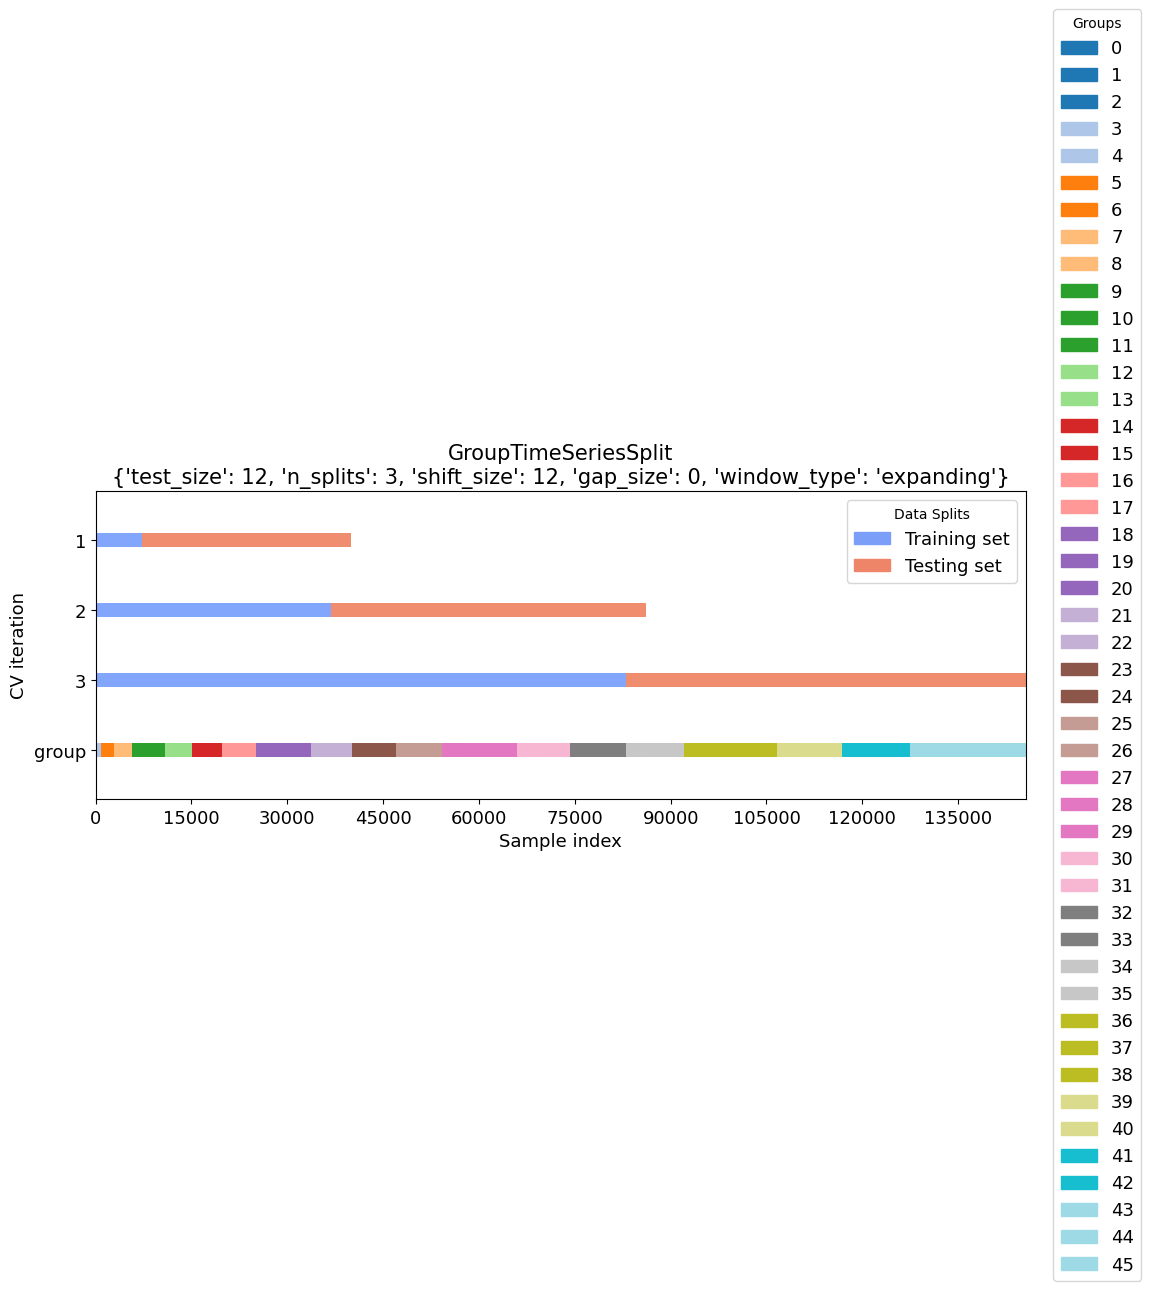

In [66]:
plot_splits(X=X_train, y=y_train, groups=train_groups, **cv_args)

#### Базовые модели для обучения

In [67]:
# логрег
logreg_base_pipeline = Pipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, solver='saga'))
])

In [68]:
# случайный лес
random_forest_base_pipeline = Pipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, max_depth=30, n_jobs=-1))
])

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Кросс-валидация настроена так:

    test_size=12
    shift_size=3
    train_size=24
    window_type="rolling"

При validation длиной 12 месяцев и сдвиге всего на 3 месяца соседние validation-периоды пересекаются на 9 месяцев

Т.е. 75% каждого следующего validation-периода уже участвовало в предыдущей оценке. Получаются не три полноценные временные проверки, а три почти одинаковых окна.

Из-за этого: CV-метрики кажутся стабильнее + Optuna несколько раз оптимизируется почти на одних и тех же месяцах и также оценка обобщающей способности становится слишком оптимистичной.

Нужно сделать три последовательных 12-месячных validation-блока без перекрытия. Например:

    test_size=12
    shift_size=12
    window_type="expanding"

Либо сформировать фолды вручную по годам. Validation всегда должен идти позже train

<div class="alert alert-info"> <b>Комментарии студента:</b> Исправил построение кросс валидации  </div>

#### Обучение кросс валидацией и оценка качества

In [69]:
def calculate_approval_metrics(y_true, y_pred, y_pred_proba):
    """
    Рассчитывает Approval Rate, Default Rate, Missed Defaults Rate
    для заданного порога.
    
    Args:
        y_true : array-like, истинные метки (1 - дефолт, 0 - ок)
        y_pred : array-like, предсказанные классы (1 - дефолт, 0 - ок)
    
    Returns:
        dict с метриками
    """
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Одобряем клиентов, для которых модель предсказала отсутствие дефолта.
    approved_mask = y_pred == 0
    n_approved = approved_mask.sum()
    n_total = len(y_true)
    
    defaults_among_approved = y_true[approved_mask].sum()
    total_defaults = y_true.sum()
    
    approval_rate = n_approved / n_total
    default_rate = defaults_among_approved / n_approved if n_approved > 0 else 0.0
    missed_defaults_rate = defaults_among_approved / total_defaults if total_defaults > 0 else 0.0
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    return {
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
    }

In [70]:
def cross_valid_cycle(
        model,
        tscv,
        X: pd.DataFrame,
        y: pd.Series,
        groups: np.ndarray,
):
    scores_list = []
    split_iterator = tscv.split(X, y, groups=groups)

    for fold, (train_index, valid_index) in enumerate(split_iterator):
        # Разделение данных для текущего фолда.
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)

        y_pred = fold_model.predict(X_valid)
        y_pred_proba = fold_model.predict_proba(X_valid)[:, 1]

        scores = calculate_approval_metrics(y_true=y_valid, y_pred=y_pred, y_pred_proba=y_pred_proba)
        scores['fold'] = fold
        scores['train_start'] = groups[train_index].min()
        scores['train_end'] = groups[train_index].max()
        scores['valid_start'] = groups[valid_index].min()
        scores['valid_end'] = groups[valid_index].max()
        scores_list.append(scores)

    return scores_list

In [71]:
def plot_score_by_folds(
        scores_list: list[dict],
        model_name: str = 'Модель',
):
    """Визуализация метрик по фолдам кросс-валидации."""

    scores_df = pd.DataFrame(scores_list).sort_values('fold')
    metric_names = {
        'approval_rate': 'Approval rate',
        'default_rate': 'Default rate',
        'missed_defaults_rate': 'Missed defaults rate',
    }
    metric_cols = list(metric_names)

    plot_df = scores_df[['fold'] + metric_cols].melt(
        id_vars='fold',
        value_vars=metric_cols,
        var_name='metric',
        value_name='score',
    )
    plot_df['metric'] = plot_df['metric'].map(metric_names)
    plot_df['score_pct'] = plot_df['score'] * 100

    fig, ax = plt.subplots()
    sns.barplot(
        data=plot_df,
        x='fold',
        y='score_pct',
        hue='metric',
        ax=ax,
    )

    ax.set_title(f'Метрики кросс-валидации: {model_name}')
    ax.set_xlabel('Фолд')
    ax.set_ylabel('Значение, %')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax.legend(title='Метрика', loc='upper left', bbox_to_anchor=(1.02, 1))

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

    if {'train_start', 'train_end', 'valid_start', 'valid_end'}.issubset(scores_df.columns):
        fold_labels = [
            f"{row.fold}\ntrain: {row.train_start}-{row.train_end}\nvalid: {row.valid_start}-{row.valid_end}"
            for row in scores_df.itertuples()
        ]
        ax.set_xticks(range(len(fold_labels)))
        ax.set_xticklabels(fold_labels)

    plt.tight_layout()
    plt.show()


def summarize_cv_metrics(
        scores_list: list[dict],
        model_name: str,
) -> pd.DataFrame:
    """Сформировать сводку средних метрик по фолдам кросс-валидации."""

    metric_cols = [
        'approval_rate',
        'default_rate',
        'missed_defaults_rate',
        'accuracy',
        'roc_auc'
    ]
    scores_df = pd.DataFrame(scores_list)

    mean_metrics = scores_df[metric_cols].mean()

    return pd.DataFrame([{
        'model': model_name,
        'n_folds': len(scores_df),
        **mean_metrics.to_dict(),
    }])

In [72]:
def mean_missed_defaults_rate(scores_list):
    scores_df = pd.DataFrame(scores_list)
    return scores_df['missed_defaults_rate'].mean()


Обучение

In [73]:
logreg_base_result = cross_valid_cycle(
    model=logreg_base_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

In [74]:
random_forest_base_result = cross_valid_cycle(
    model=random_forest_base_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

Результаты

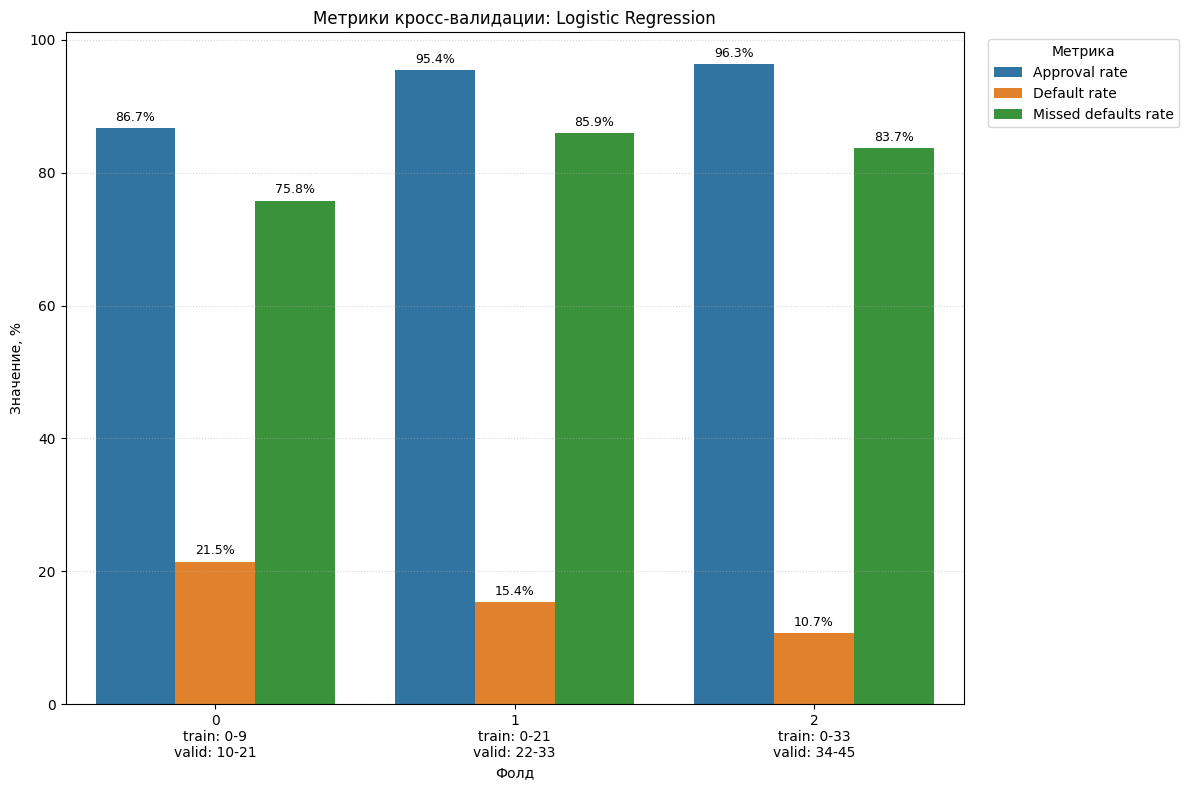

In [75]:
plot_score_by_folds(logreg_base_result, model_name='Logistic Regression')

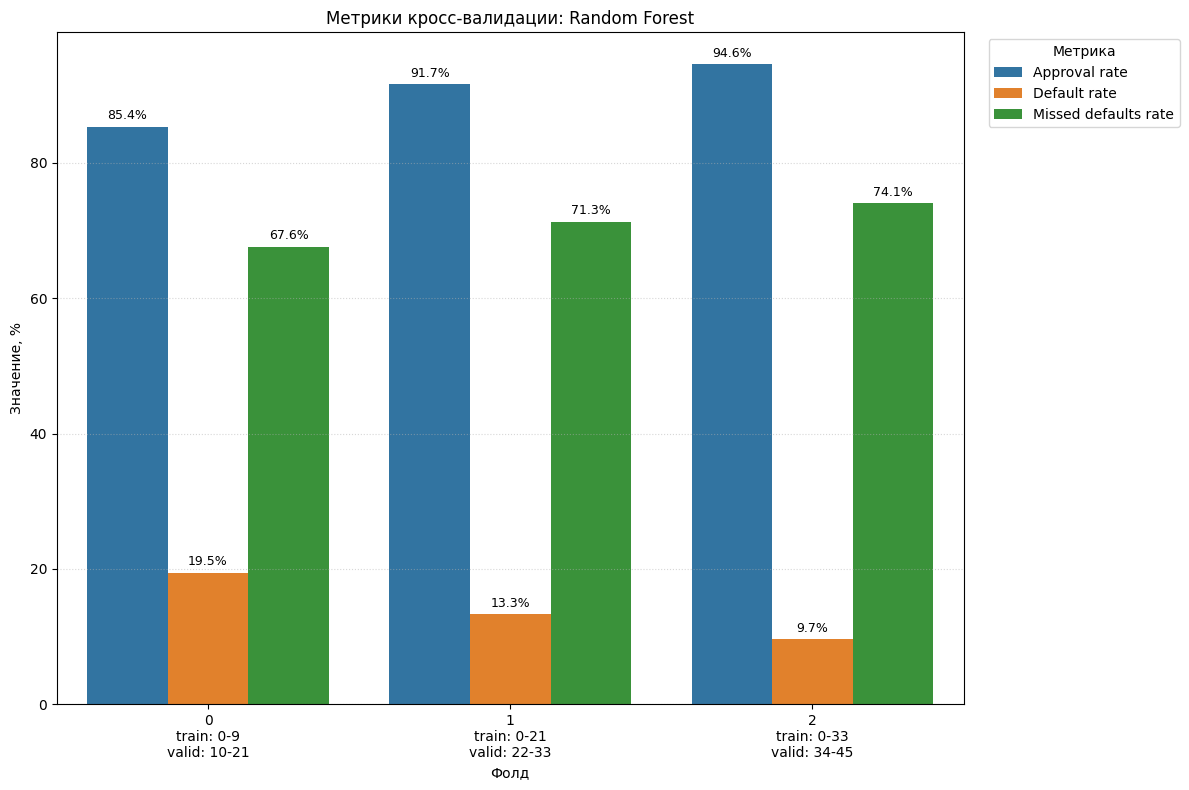

In [76]:
plot_score_by_folds(random_forest_base_result, model_name='Random Forest')

In [77]:
# сохранение результата
models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_base_result,
        'Logistic Regression',
    ),
    summarize_cv_metrics(
        random_forest_base_result,
        'Random Forest',
    ),
], ignore_index=True)
models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.928002,0.158642,0.817808,0.817148,0.806868
1,Random Forest,3,0.905510,0.141451,0.710184,0.832477,0.842388


#### Выводы по работе базовых моделей

- по метрике Approval rate базовые модели показывают высокие результаты (более 90%). Модели предсказывают высокую долю клиентов, которые являются надежными. Это можно объяснить тем, что надежных клиентов существенное большинство и, даже при плохой способности предсказывать, у модели на несбалансированных классах может быть высоким этот показатель.
- по метрикам default rate и missed defaults значения на порядок выше требований. Это связано с тем, что ненадежных клиентов достаточно мало и модели на несбалансированных классах плохо предсказывают редкий класс дефолтов

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
ROC-AUC сейчас рассчитывается по готовым классам:

    roc_auc_score(y_true, y_pred)

Так считать ROC-AUC нельзя. Метрика должна оценивать качество ранжирования и рассчитываться по вероятностям:

    y_proba = model.predict_proba(X_valid)[:, 1]
    Йroc_auc = roc_auc_score(y_valid, y_proba)

Классы нужны только для accuracy и бизнес-метрик. Из-за этой ошибки все значения ROC-AUC базовых моделей и вывод о выборе лучшей модели сейчас недостоверны.

---

Логистическая регрессия не сходится. В выводах есть:

    ConvergenceWarning
    overflow
    invalid value
    достижение лимита итераций

Пока модель не сошлась, её метрики нельзя считать надёжными.

Нужно:

* проверить трансформированные признаки на inf и слишком большие значения
* проверить income_spend_ratio_3m
* увеличить max_iter
* при необходимости выбрать другой solver
* убедиться, что после полного запуска предупреждений о сходимости нет

<div class="alert alert-info"> <b>Комментарии студента:</b> Исправил расчет ROC-AUC. Увеличил количество итераций для LogReg </div>

### Работа с дисбалансом классов

- в исходных данных дисбаланс умененный (миноритарного класса более 10%)
- применяется подход генерации синтетики


In [78]:
y_train.value_counts() / len(y_train)

target
0    0.830142
1    0.169858
Name: count, dtype: float64

In [79]:
# генерация синтетических объектов редкого класса
smote_sampler = SMOTE(
    k_neighbors=3,
    sampling_strategy=0.5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)


Обновленные пайплайны с балансировщиками

In [80]:
# логрег
logreg_base_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, solver='saga'))
])

In [81]:
# случайный лес
random_forest_base_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, max_depth=50))
])

Обучение 

In [82]:
logreg_base_balanced_result = cross_valid_cycle(
    model=logreg_base_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Us

In [83]:
random_forest_balanced_result = cross_valid_cycle(
    model=random_forest_base_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/User

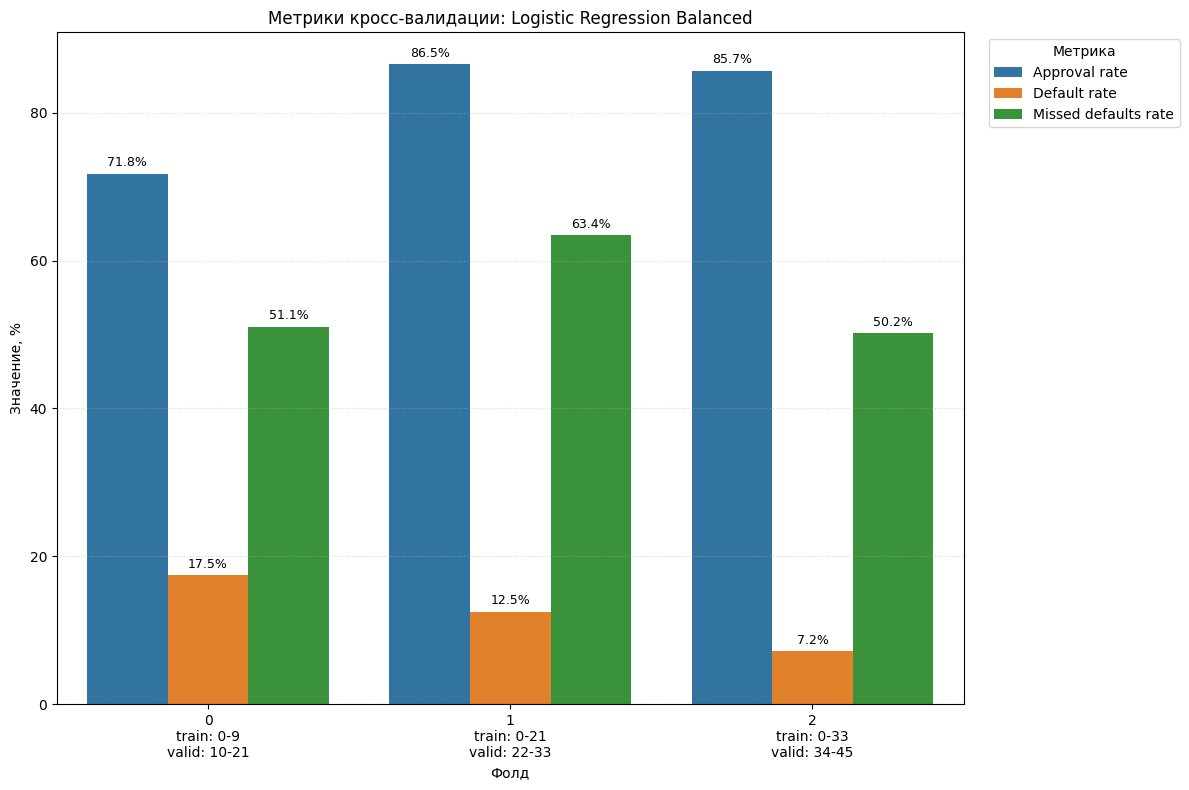

In [84]:
plot_score_by_folds(logreg_base_balanced_result, model_name='Logistic Regression Balanced')

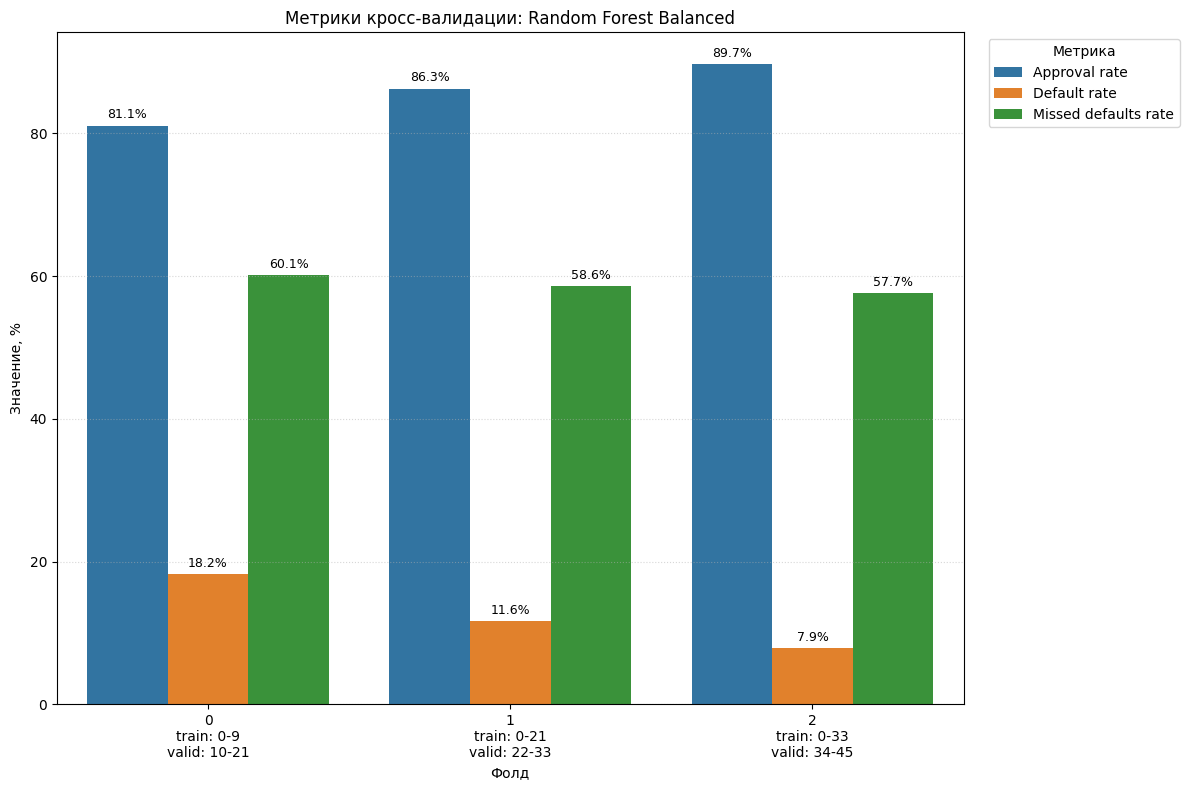

In [85]:
plot_score_by_folds(random_forest_balanced_result, model_name='Random Forest Balanced')

In [86]:
balanced_models_summary = pd.concat([
    summarize_cv_metrics(
        logreg_base_balanced_result,
        'Logistic Regression Balanced',
    ),
    summarize_cv_metrics(
        random_forest_balanced_result,
        'Random Forest Balanced',
    ),
], ignore_index=True)

balanced_models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression Balanced,3,0.813235,0.124175,0.548926,0.796011,0.806625
1,Random Forest Balanced,3,0.856587,0.125976,0.588173,0.823809,0.843763


In [87]:
models_summary = pd.concat([
    models_summary,
    balanced_models_summary,
], ignore_index=True)

models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.928002,0.158642,0.817808,0.817148,0.806868
1,Random Forest,3,0.905510,0.141451,0.710184,0.832477,0.842388
2,Logistic Regression Balanced,3,0.813235,0.124175,0.548926,0.796011,0.806625
3,Random Forest Balanced,3,0.856587,0.125976,0.588173,0.823809,0.843763


Анализ:
- балансировка положительно повлияла на способность моделей выявлять редкий класс. Значения усредненных метрик default_rate и missed_defaults_rate существенно снизились. default_rate снизился на ~20% для обеих моделей, missed_defaults_rate снизился на ~30%
- модель стала чаще ошибаться в предсказаниях более распространенного класса, что выражается в снижении метрики approval_rate на ~10%
- в целом эффект от балансировки стоит рассматривать как положительный: для решения поставленной бизнесом задачи гораздо важнее обнаруживать редкий класс

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Тут вижу что сравниваются четыре обязательные базовые модели

---
## 6. Подбор гиперпараметров модели

### Оптимизация параметров для RandomForestClassifier

In [88]:
def objective_random_forest(trial):
    """
    Функция-цель для оптимизации параметров случайного леса
    """

    # Пространство поиска
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 20, 80),   # глубина дерева
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 100), # минимальное число объектов для разбиения
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50), # минимальное число объектов в листе
        "criterion": trial.suggest_categorical("criterion", ['gini', 'entropy', 'log_loss']),  # функция качества
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.05),
        'class_weight':  trial.suggest_categorical("class_weight", ['balanced', 'balanced_subsample']), 
    }

    # случайный лес
    pipeline = ImbPipeline(steps=[
        ('preproc', create_preprocessing_pipeline()),
        ('model', RandomForestClassifier(**params, random_state=RANDOM_SEED, n_jobs=-1))
    ])

    scores = cross_valid_cycle(
        model=pipeline, 
        tscv=tscv, 
        X=X_train,
        y=y_train,
        groups=train_groups,
    )
    
    
    return mean_missed_defaults_rate(scores)


In [89]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study_random_forest = optuna.create_study(direction="minimize", sampler=sampler) 

[I 2026-06-14 20:20:11,648] A new study created in memory with name: no-name-7c3e6ebb-faf4-431e-ac32-3c01384b0b8e


In [90]:
# запуск оптимизации
study_random_forest.optimize(objective_random_forest, n_trials=30, show_progress_bar=True) 

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-14 20:20:13,830] Trial 0 finished with value: 0.07086630921447767 and parameters: {'n_estimators': 42, 'max_depth': 77, 'min_samples_split': 79, 'min_samples_leaf': 34, 'criterion': 'gini', 'ccp_alpha': 0.04330880728874676, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.07086630921447767.
[I 2026-06-14 20:20:15,274] Trial 1 finished with value: 0.07078678168011314 and parameters: {'n_estimators': 21, 'max_depth': 79, 'min_samples_split': 87, 'min_samples_leaf': 18, 'criterion': 'log_loss', 'ccp_alpha': 0.026237821581611892, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.07078678168011314.
[I 2026-06-14 20:20:18,058] Trial 2 finished with value: 0.07193874686886875 and parameters: {'n_estimators': 57, 'max_depth': 28, 'min_samples_split': 43, 'min_samples_leaf': 25, 'criterion': 'entropy', 'ccp_alpha': 0.02571172192068058, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.07078678168011314.
[I 2026-06-14 20:20:20,463] Trial 3 finishe

In [91]:
display(study_random_forest.best_params, study_random_forest.best_value)

{'n_estimators': 46,
 'max_depth': 47,
 'min_samples_split': 90,
 'min_samples_leaf': 29,
 'criterion': 'entropy',
 'ccp_alpha': 0.04636319358537332,
 'class_weight': 'balanced_subsample'}

0.06592293448841016

In [92]:
random_forest_opt_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED, **study_random_forest.best_params))
])

In [93]:
random_forest_opt_result = cross_valid_cycle(
    model=random_forest_opt_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

#### Сравнение моделей

In [94]:
optimized_models_summary = summarize_cv_metrics(
        random_forest_opt_result,
        'Random Forest Opt',
    )



In [95]:
models_summary = pd.concat([models_summary, optimized_models_summary], ignore_index=True)
models_summary

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
0,Logistic Regression,3,0.928002,0.158642,0.817808,0.817148,0.806868
1,Random Forest,3,0.905510,0.141451,0.710184,0.832477,0.842388
2,Logistic Regression Balanced,3,0.813235,0.124175,0.548926,0.796011,0.806625
3,Random Forest Balanced,3,0.856587,0.125976,0.588173,0.823809,0.843763
4,Random Forest Opt,3,0.478961,0.030718,0.065923,0.634324,0.801487


#### Анализ

Подбор гиперпараметров позволил существенно снизить метрики: default_rate и missed_defaults_rate. 
- default_rate для моделей в диапазоне 2-4%, что ниже показателей базовых моделей в 5-6 раз. 
- missed_defaults_rate для LogReg снижено в 4,7 раза, для Random Forest метрика снижена в 7 раз относительно базовой модели

Можно сделать вывод, что оптимизация параметров позволила моделям лучше определять редкий класс.

Метрика approval_rate при этом снизилась примерно на 30% относительно базовых моделей. Это можно объяснить тем, что модели стали чаще ошибаться в предсказании более распространенного класса.

### Применение оптимальных параметров + балансировка

In [96]:
random_forest_opt_balanced_pipeline = ImbPipeline(steps=[
    ('preproc', create_preprocessing_pipeline()),
    ('oversampler', smote_sampler),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED, **study_random_forest.best_params))
])
random_forest_opt_balanced_result = cross_valid_cycle(
    model=random_forest_opt_balanced_pipeline,
    tscv=tscv,
    X=X_train,
    y=y_train,
    groups=train_groups,
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/User

### Выбор лучшей модели

In [97]:
optimized_balanced_models_summary = summarize_cv_metrics(
        random_forest_opt_balanced_result,
        'Random Forest Opt Balanced',
    )

In [98]:
models_summary = pd.concat([models_summary, optimized_balanced_models_summary], ignore_index=True)


In [99]:
models_summary.sort_values(by=['accuracy', 'roc_auc'], ascending=True)

,model,n_folds,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc
4,Random Forest Opt,3,0.478961,0.030718,0.065923,0.634324,0.801487
5,Random Forest Opt Balanced,3,0.485316,0.032640,0.072675,0.638523,0.804715
2,Logistic Regression Balanced,3,0.813235,0.124175,0.548926,0.796011,0.806625
0,Logistic Regression,3,0.928002,0.158642,0.817808,0.817148,0.806868
3,Random Forest Balanced,3,0.856587,0.125976,0.588173,0.823809,0.843763
1,Random Forest,3,0.905510,0.141451,0.710184,0.832477,0.842388


In [100]:
# лучшая модель
best_model = RandomForestClassifier(**study_random_forest.best_params, random_state=RANDOM_SEED)


Итог:

- по метрикам accuracy,	roc_auc была отобрана лучшая модель --  случайный лес с подобранными с помощью Optuna параметрами


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Параметр l1_ratio подбирается вместе с:

    penalty="l2"

При L2-регуляризации l1_ratio вообще не используется, о чём прямо сообщают предупреждения sklearn.

Нужно либо:

* убрать l1_ratio
* либо использовать penalty="elasticnet" и совместимый solver saga

Также необходимо исправить проблему сходимости модели

Оптимизация Logistic Regression не обязательна для проекта, поэтому этот блок можно убрать, если не планируется его корректно дорабатывать

<div class="alert alert-info"> <b>Комментарии студента:</b> убрал оптимизацию LogReg  </div>

---
## 7. Калибровка модели и пересчёт результатов

In [101]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [102]:
def get_calib_metrics(y_calib, model_probabilities, sort_by=['brier_score']):
    """Резельтат калибровки"""
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_calib, y_proba),
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [103]:
def get_calibrated_model(model, X_train, y_train, X_calib, y_calib, method='isotonic'):
    preprocessor = create_preprocessing_pipeline()
    preprocessor.fit(X_train, y_train)
    X_train_prep = preprocessor.transform(X_train)
    X_calib_prep = preprocessor.transform(X_calib)

    base_model = clone(model)
    base_model.fit(X_train_prep, y_train)

    calibrated_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model),   
        method=method,
        cv='prefit',                            
        n_jobs=-1
    )
    calibrated_model.fit(X_calib_prep, y_calib)

    return preprocessor, base_model, calibrated_model

In [104]:
# Обучение с калибровкой 
best_model_preprocessor, best_model, best_model_calibrated = get_calibrated_model(
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_calib, 
    y_calib=y_calib,
    method='isotonic',
)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [105]:
best_pipeline = ImbPipeline(steps=[
    ('preproc', best_model_preprocessor),
    ('model', best_model_calibrated),
])

In [106]:
X_calib_prep = best_model_preprocessor.transform(X_calib)

y_calib_proba_calibrated = best_model_calibrated.predict_proba(X_calib_prep)[:, 1]

y_calib_proba = best_model.predict_proba(X_calib_prep)[:, 1]

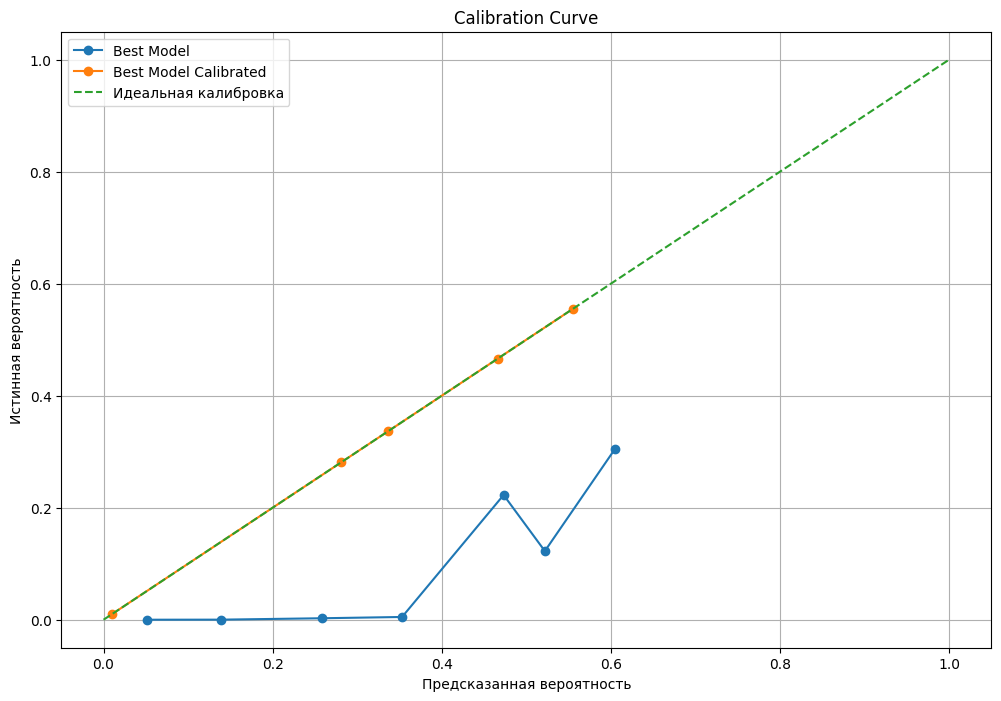

In [107]:
plot_calibration_curve(
    y_calib, 
    [y_calib_proba, y_calib_proba_calibrated],
    names=['Best Model', 'Best Model Calibrated'],
    n_bins=10
)

In [108]:
model_probabilities = {
    'Best Model Uncalib': y_calib_proba,
    'Best Model Calib': y_calib_proba_calibrated,
}

In [109]:
get_calib_metrics(
    y_calib,
    model_probabilities,
)


,model,brier_score
0,Best Model Calib,0.070267
1,Best Model Uncalib,0.137754


#### Анализ

- график калибровки показывает, что вероятности, предсказывемые моделью теперь гораздо лучше отражают реальные частоты, с которыми встречаются классы при различных порогах по вероятности 
- метрика калибровки brier_score - среднеквадратичная ошибка вероятности прогноза уменьшена на 30%, что подтверждает положительное влияние калибровки

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, что основная модель сначала обучается на train, а calibration не используется при её обучении

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Калибровочная кривая и Brier Score считаются на test:

    plot_calibration_curve(y_test, ...)
    get_calib_metrics(y_test, ...)

Получается, что test используется ещё до подбора порога и финального анализа матрицы ошибок. Test должен оставаться полностью независимой финальной проверкой. В этом разделе нужно анализировать калибровку на calibration-выборке, а test использовать только один раз в разделе 8 после фиксации порога.

После исправления CV и обработки пропусков калибровку также нужно выполнить заново

<div class="alert alert-info"> <b>Комментарии студента:</b> Провел оценку калибровки по калибровочной выборке. На графике точке легли по диагонали для откалиброванной модели. Кажется, чтобы по графику корректно оценивать эффект калибровки, нужно подавать какую-то ранее неиспользованную выборку. По крайней мере в прошлых проектах так делал.  </div>

### Поиск порога решения

* значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    

In [110]:
# Настраиваем порог
tuned_clf = TunedThresholdClassifierCV(
    estimator=best_pipeline,
    scoring='neg_brier_score'
)
tuned_clf.fit(X_calib, y_calib)

# Выводим найденный порог
best_th = tuned_clf.best_threshold_
print(f"Оптимальный порог: {best_th:.3f}")

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated 

Оптимальный порог: 0.200


/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


#### Итог
- подобран оптимальный порог

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Порог необходимо подобрать заново после исправления

<div class="alert alert-info"> <b>Комментарии студента:</b> Внес исправления  </div>

---
## 8. Анализ матрицы ошибок

In [111]:
# Предсказания на калибровочном множестве
proba_calib = best_pipeline.predict_proba(X_calib)[:, 1]
y_calib_true = y_calib.values.ravel() if hasattr(y_calib, 'values') else y_calib

# оптимальный порог
threshold = best_th
y_calib_pred = (proba_calib > threshold).astype(int)

# Предсказания на тестовом множестве
proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_test_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_test_pred = (proba_test > threshold).astype(int)

In [112]:
def plot_confusion_matrices(y_true_cal, y_pred_cal, y_true_test, y_pred_test, class_names=['Норм - 0', 'Дефолт - 1']):
    fig, axes = plt.subplots(1, 2)

    # Матрица на калибровочных данных
    cm_cal = confusion_matrix(y_true_cal, y_pred_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, display_labels=class_names)
    disp_cal.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Матрица ошибок - Калибровочные данные')

    # Матрица на тестовых данных
    cm_test = confusion_matrix(y_true_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
    disp_test.plot(ax=axes[1], cmap='Blues', values_format='d')
    axes[1].set_title('Матрица ошибок -  Тестовые данные')

    plt.tight_layout()
    plt.show()

    return cm_cal, cm_test

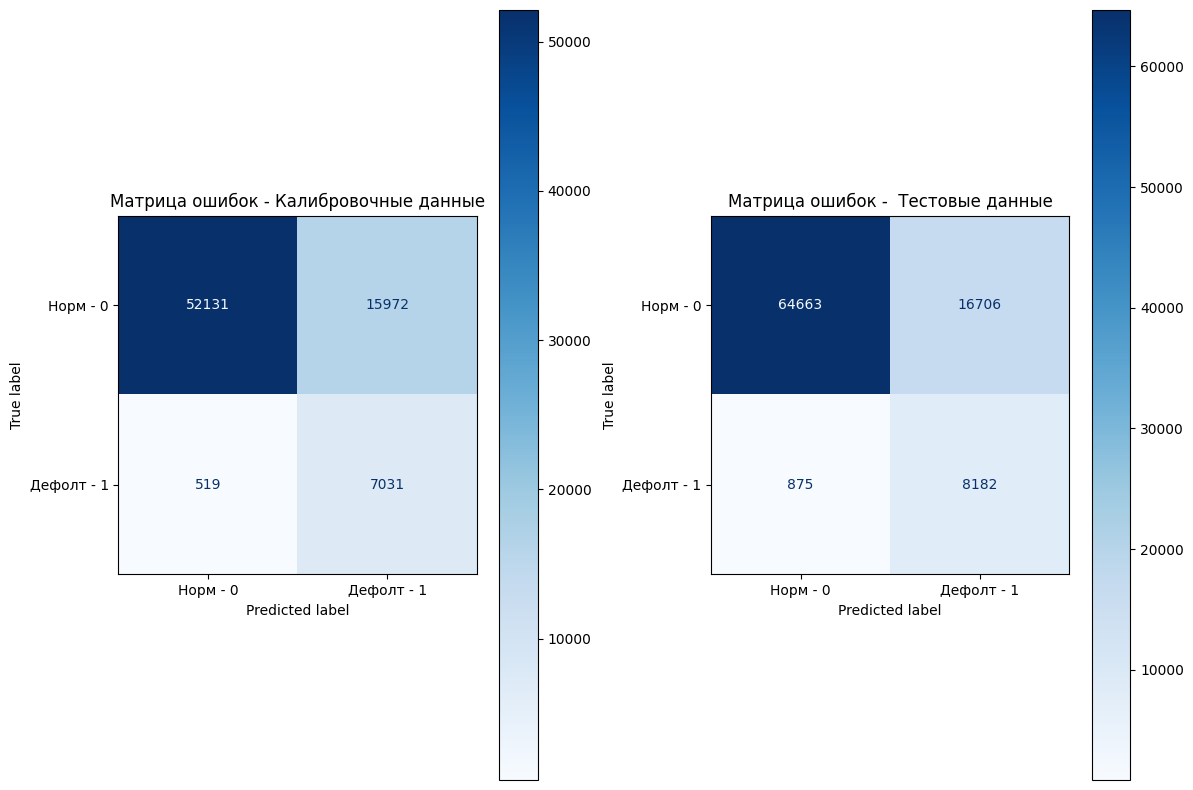

(array([[52131, 15972],
        [  519,  7031]]),
 array([[64663, 16706],
        [  875,  8182]]))

In [113]:
cm_cal, cm_test = plot_confusion_matrices(y_calib_true, y_calib_pred, y_test_true, y_test_pred)
cm_cal, cm_test

In [114]:
print('Калибровка: ')
print(classification_report(y_calib_true, y_calib_pred, target_names=['Норм', 'Дефолт']))

Калибровка: 
              precision    recall  f1-score   support

        Норм       0.99      0.77      0.86     68103
      Дефолт       0.31      0.93      0.46      7550

    accuracy                           0.78     75653
   macro avg       0.65      0.85      0.66     75653
weighted avg       0.92      0.78      0.82     75653



In [115]:
print('Тест: ')
print(classification_report(y_test_true, y_test_pred, target_names=['Норм', 'Дефолт']))

Тест: 
              precision    recall  f1-score   support

        Норм       0.99      0.79      0.88     81369
      Дефолт       0.33      0.90      0.48      9057

    accuracy                           0.81     90426
   macro avg       0.66      0.85      0.68     90426
weighted avg       0.92      0.81      0.84     90426



In [116]:
def calc_business_metrics(y_true, y_pred):
    """Расчёт approval rate, default rate, missed defaults rate."""
    n_total = len(y_true)
    n_approved = (y_pred == 0).sum()
    n_defaults = (y_true == 1).sum()

    ar = n_approved / n_total
    dr = y_true[y_pred == 0].mean() if n_approved > 0 else np.nan
    mdr = ((y_pred == 0) & (y_true == 1)).sum() / n_defaults if n_defaults > 0 else np.nan
    return ar, dr, mdr

In [117]:
ar_cal, dr_cal, mdr_cal = calc_business_metrics(y_calib_true, y_calib_pred)
ar_test, dr_test, mdr_test = calc_business_metrics(y_test_true, y_test_pred)

print("\n--- Сравнение ключевых бизнес метрик ---")
print(f"{'Метрика':<25} {'Калибровка':>15} {'Тест':>15}")
print(f"{'Approval Rate':<25} {ar_cal:>15.3f} {ar_test:>15.3f}")
print(f"{'Default Rate':<25} {dr_cal:>15.4f} {dr_test:>15.4f}")
print(f"{'Missed Defaults Rate':<25} {mdr_cal:>15.4f} {mdr_test:>15.4f}")


--- Сравнение ключевых бизнес метрик ---
Метрика                        Калибровка            Тест
Approval Rate                       0.696           0.725
Default Rate                       0.0099          0.0134
Missed Defaults Rate               0.0687          0.0966


#### Итог:

- матрица ошибок имеет схожий вид на калибровке и тесте. Ключевые для бизнеса ошибки сведены к минимуму: предсказания отсутствия дефолта при истинном дефолте малочисленны.
- модель ведет себя достаточно стабильно: на тестовых данных ключевые метрики показывают умеренное ухудшение по сравнению с калибровкой. Требования по ключевым метрикам default rate и approval rate на calibrate/test выполняются, по MDR не удалось достичь целевого показателя

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Требование по MDR - не выше 4%. Модель пропускает более чем в два раза больше дефолтов, чем допускает бизнес-задача
    
Но в выводе написано:

    "ключевые метрики по-прежнему удовлетворяют требованиям"

<div class="alert alert-info"> <b>Комментарии студента:</b> Внес изменения, но по MDR пока не удается достичь целевого показателя </div>

---
## 9. Фиксирование итоговой модели

Лучшая модель: 
- случайный лес с оптимизированными на тренировочной выборке параметрами с помощью пайплайна с кросс валидацией
- на калибровочной выборке подобрано значение вероятности, которое позволяет достичь целевых показателей по ключевым метрикам


In [132]:
class ThresholdCalibratedClassifier(BaseEstimator, ClassifierMixin):
    """
    Принимает уже обученный препроцессор, калиброванную модель и порог.
    Метод predict возвращает 1 если откалиброванная вероятность > threshold,
    иначе 0.
    """
    def __init__(self, pipeline, threshold):
        self.pipeline = pipeline
        self.threshold = threshold

    def fit(self, X, y):
        self.pipeline.fit(X, y)

    def predict_proba(self, X):
        """Возвращает вероятности класса 1 (дефолт)."""
        return self.pipeline.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba > self.threshold).astype(int)


In [133]:
final_model = ThresholdCalibratedClassifier(
    pipeline=best_pipeline,
    threshold=best_th
)
final_model

ThresholdCalibratedClassifier(pipeline=Pipeline(steps=[('preproc',
                                                        ColumnTransformer(transformers=[('cat_one_hot_pipeline',
                                                                                         Pipeline(steps=[('imputer',
                                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                                         ('encoder',
                                                                                                          OneHotEncoder(drop='first',
                                                                                                                        handle_unknown='ignore',
                                                                                                                        sparse_output=False))]),
                                                                                         <function select_cat_one_hot at 0x327c7ef70>),
                                                                                        ('num_special_mf_pipeline',
                                                                                         Pipe...
                                                                                         <function select_num_classic at 0x327c7e160>)])),
                                                       ('model',
                                                        CalibratedClassifierCV(cv='prefit',
                                                                               estimator=FrozenEstimator(estimator=RandomForestClassifier(ccp_alpha=0.04636319358537332,
                                                                                                                                          class_weight='balanced_subsample',
                                                                                                                                          criterion='entropy',
                                                                                                                                          max_depth=47,
                                                                                                                                          min_samples_leaf=29,
                                                                                                                                          min_samples_split=90,
                                                                                                                                          n_estimators=46,
                                                                                                                                          random_state=42)),
                                                                               method='isotonic',
                                                                               n_jobs=-1))]),
                              threshold=np.float64(0.2001430314248454))

---
## 10. Анализ важности признаков


In [142]:
rf_model = final_model.pipeline[1].estimator.estimator

preprocessor = final_model.pipeline[0]

In [143]:
importances = rf_model.feature_importances_
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(len(importances))]

# Сортируем по убыванию
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_names = feature_names[indices]

In [144]:
top_n = 20
print(f"Топ-{top_n} признаков по важности для модели RandomForest:")
for i in range(min(top_n, len(sorted_names))):
    print(f"{sorted_names[i]:45s} {sorted_importances[i]:.4f}")

Топ-20 признаков по важности для модели RandomForest:
num_classic_pipeline__income_spend_ratio_3m   0.3170
num_classic_pipeline__MCC_3990_sum_3m         0.1506
num_classic_pipeline__MCC_5411_sum_3m         0.1205
num_classic_pipeline__MCC_другое_sum_3m       0.0749
num_classic_pipeline__MCC_5722_sum_3m         0.0715
num_classic_pipeline__MCC_5812_sum_3m         0.0550
num_classic_pipeline__MCC_другое_sum_6m       0.0435
num_classic_pipeline__MCC_3990_sum_6m         0.0435
num_classic_pipeline__MCC_5300_sum_3m         0.0381
num_classic_pipeline__MCC_5814_sum_3m         0.0217
num_classic_pipeline__MCC_5814_sum_6m         0.0217
num_classic_pipeline__доход                   0.0172
num_classic_pipeline__MCC_4900_sum_3m         0.0107
num_classic_pipeline__MCC_5300_sum_6m         0.0083
num_classic_pipeline__MCC_4900_sum_6m         0.0058
num_special_zero_pipeline__наличие_ипотеки    0.0000
num_special_mf_pipeline__наличие_иждивенцев   0.0000
cat_one_hot_pipeline__семейное_положение_разв

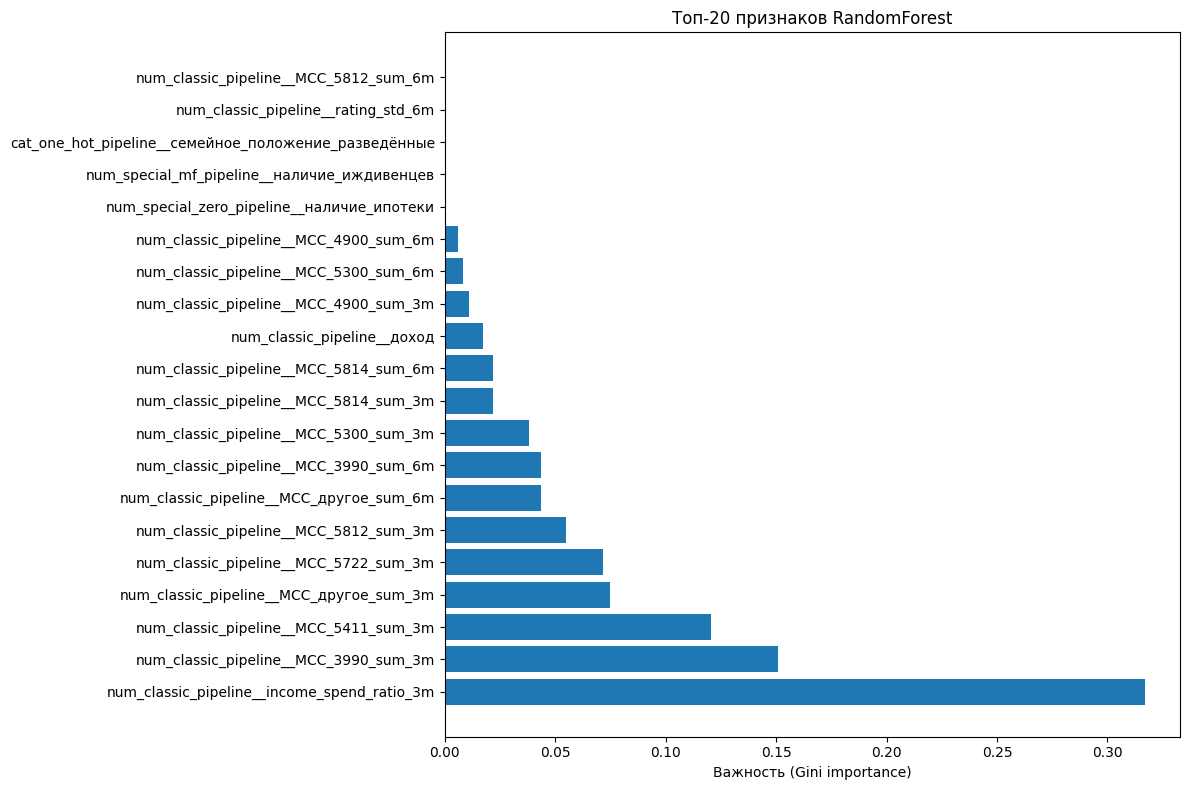

In [145]:
plt.barh(range(top_n), sorted_importances[:top_n][::-1])
plt.yticks(range(top_n), sorted_names[:top_n][::-1])
plt.xlabel('Важность (Gini importance)')
plt.title(f'Топ-{top_n} признаков RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

### Цель и задачи исследования.

Целью исследования было построение модели поведенческого скоринга для предсказания по историческим данным вероятности дефолта клиента в ближайшие 12 месяцев

Среди задач можно отметить:
- загрузка датасета
- исследовательский анализ данных
- формирования итоговой таблицы
- обучение базовых моделей: логичстической регрессии и случайного леса
- обработка дисбаланса классов целевой переменной и оптимизация параметров моделей
- проведение сравнительного анализа и выбор лучшей модели 
- калибровка лучшей модели и выбор оптимального порога по вероятности для предсказания модели
- проверка выполнения требований заказчика по ключевым метрикам на тестовых данных, оценка стабильности модели 
- оценка важности признаков

###  Подготовка данных и выборок.

#### ИАД 

#### Общие сведения

Данные представлены в виде 8 таблиц:
- Данные о просрочке платежа: loan_payment_credit
- Месячные транзакции клиента: transactions
- Описание клиента на момент регистрации в банке: client_description
- Описание кредита: credit_description
- Данные о наличии ипотеки: mortgage_presence
- Данные о кредитном рейтинге клиента: credit_rating
- Данные о макроэкономических показателях России: macro_data
- Данные о дате проведения поведенческого скоринга: cohort_grid

Типы данных соотвествуют описанию. 

#### Пропуски, дубли

- явных и неявных пропусков/дублей в данных не обнаружено


#### Анализ распределений

Количественные данные:
- loan_payment_credit: значение дней просрочек равномерно распределено по диапазону
- transactions: траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- client_description: по возрасту распределение равномерное
- client_description: наличие иждевенцев представлено в примерно равных долях 
- credit_description: по доходу и сумме кредита распределение равномерное 
- mortgage_presence: данные по наличию ипотеки принимают одно значнение - 1
- credit_rating: распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Выдвинуто предположение, что в происходило округление или имеются стандратные рейтинги для каких-то категорий граждан.
- macro_data: Распределение по учетной ставке несимметричное и имеет малый набор уникальных значений
- macro_data: По безработице распределение симметричное без выбросов
- macro_data: По инфляции распределение симметричное, есть выбросы 

Категориальные данные:
- loan_payment_credit: дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- client_description: по признаку семейного пложения дисбаланса нет 
- mortgage_presence: по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки


#### Анализ целевой переменной

- наблюдается дисбаланс классов. Для более точного прогноза модели предложено использовать балансировку


### Формирование итоговой таблицы

Данные из 8-ми указанных выше таблиц сведены в один датасет. 
Итоговая таблица представляет собой временной ряд: на каждый месяц в заданном промежутке времени имеются данные по активности пользователей и общие макроэкономические данные.
Таблица дополнена новыми признаками для каждого уникального клиента: средние расходы по категорям и отношение дохода к расходу за 3 последние месяца.

- таблица состоит из 29 столбцов-признаков, характеризующих клиентов и макроэкономическую ситуацию в стране 
- кроме того, таблица содержит: target - целевая переменная, score_date - дата оценки, ID - идентификатор пользователя

### Пайплайн предобработки 

Категориальные данные закодированы с помощью OneHot.
Признаки масштабированы.
Потери при фильтрации пропусков составили около 7%.
Стоит заметить, что масштабирование и обработка выбросов не обязательны для обучения случайного леса. Это сделано для универсальности пайплайна.


### Поиск и настройка модели.

- данные разделены на три выборки: train/calib/test
- применена кросс валидация на трех фолдах с группировкой по месяцам 
- обучены две модели на базовых настройках: логистическая регрессия и случайный лес
- для обработки дисбаланса классов выбран метод генерации синтетики: дисбланс несильный и объектов миноритарного класса довольно много в выборке, поэтому подход позволяет сгенерировать довольно качественные объекты редкого класса. 
В результате балансировки ключевые метрики базовыз моделей существенно улучшаются, что подтверждает применимость подхода.
- проведена оптимизация параметров моделей с помощью библиотеки Optuna. Модели с оптимизированными параметрами существенно превосходят базовые модели по ключевым метрикам.
- проведен отбор лучшей модели: случайный лес после оптимизации параметров


4. Калибровка вероятностей.
- к лучшей модели с предыдущего этапа применена калибровка. 
- график калибровочных кривых и оценка бриера позволяет сделать вывод: калиброванная модель лучше отражает реальную частоту появления целевого класса в данных. То есть калибровка проведена корректно 

5. Оптимизация бизнес-порога.
- проведен подбор порога по вероятности предсказания целевого класса. Полученные ключевые метрики удовлетворяют требованиям заказчика.


6. Анализ важности признаков.
наиболее важными признаками модели являются: 
- соотношение доход/расход за 3 последних месяца. Изменение этого показателя может быть интерпретирован как сигнал, что клиент начал тратить больше, чем зарабатывает и вероятнее всего не может закрыть платеж по кредиту в ближайщем будущем.
- доход клиента - ожидаемо довольно важный показатель. Можно предположить, что чем ниже доход, тем меньше веротность выплаты по кредиту
- траты за последние 3 месяца также входят в топ по важности. Рост трат может быть сигналом для прогноза дефолта

7. Финальный пайплайн.
Итоговый пайплайн состоит из: 
- пайплайна предобработки данных с обработкой категоральных данных и обработкой пропусков, масштабированием признаков  
- модели случайного леса обученного на train с кросс валидацией на 3х фолдах и с подобранными гиперпараметрами. 
- Модель откалибрована и содердит оптимальный порог по вероятности.
- требования по ключевым метрикам выполнены для Approval rate и Default rate, при этом по Missed defaults rate модель показывает превышение требуемого порога в 2 раза

8. Основные выводы и рекомендации для бизнеса.

Разработанная модель оптимизирована по гиперпараметрам, показывает стабильное качество предсказаний, удовлетворяет бизнес требованиям по качеству по 2 из 3 ключевых метрик.
Как показал проведенный анализ, стоит обращать внимание на соотношение доход/расход за последние несколько месяцев, чтобы предсказать дефолт клиента ближайшее время.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

По структуре ОК, просьба скорректировать после правок

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Вижу у тебя проект почти на 250 ячеек кода. Мой совет - лучше не стоит настолько раздувать проект, получается много лишнего, что не требуется в проекте